# Liverpool Energy Performance Certificate (EPC) Analysis
## COM6003 Data Science — Buckinghamshire New University 2025–26

**Dataset:** Energy Performance of Buildings — Liverpool Local Authority (E08000012)
**Source:** Ministry of Housing, Communities and Local Government (MHCLG) Open Data Portal
**Student:** Muhammad Omer | **Submission deadline:** 18 June 2026

---

This notebook presents a complete end-to-end data science pipeline applied to 4,579 residential EPC records from Liverpool. The analysis follows the four-stage analytics hierarchy:

| Stage | Question answered | Sections |
|---|---|---|
| Descriptive | What has occurred? | 4 — Descriptive Analytics |
| Diagnostic | Why did it happen? | 5 — Diagnostic Analytics |
| Predictive | What will happen? | 6–7 — Classification & Regression |
| Prescriptive | What should we do? | 8–9 — Clustering & Recommendations |

**Key methodological decision — data leakage prevention:** The SAP-derived column `CURRENT_ENERGY_EFFICIENCY` numerically encodes the target variable `CURRENT_ENERGY_RATING` (92+ = A, 81–91 = B, etc.). Including it in the feature set would inflate model accuracy to near-perfect and produce a model with no real-world validity. All 25 predictive features are therefore restricted to *physical building characteristics* — properties an assessor can observe before the SAP calculation is run (Kaufman et al., 2012).


## Section 1: Data Acquisition and Understanding

The raw dataset contains 5,000 EPC records for Liverpool (Local Authority E08000012) exported from the MHCLG Open Data Portal. This section establishes the shape, completeness, and quality of the data before any transformation is applied.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize']   = 11
plt.rcParams['xtick.labelsize']  = 10
plt.rcParams['ytick.labelsize']  = 10
sns.set_theme(style='whitegrid', palette='muted')

RATING_COLORS = {'A':'#2ecc71','B':'#27ae60','C':'#f1c40f','D':'#e67e22','E':'#e74c3c'}
AGE_COLORS    = ['#8e44ad','#2980b9','#27ae60','#f39c12','#e67e22','#e74c3c','#1abc9c']
PALETTE       = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
EFF_COLORS    = ['#2ecc71','#27ae60','#f1c40f','#e67e22','#e74c3c']
CLUSTER_COLORS= ['#3498db','#e74c3c','#2ecc71','#f39c12']
AGE_ORDER     = ['Pre-1900','1900-1949','1950-1975','1976-1990','1991-2002','2003-2021','Post-2021']
EFF_ORDER     = ['Very Good','Good','Average','Poor','Very Poor']

def bar_labels(ax, bars, values, total=None, fmt=',.0f', offset_pct=0.015, fontsize=9.5):
    span = ax.get_ylim()[1] - ax.get_ylim()[0]
    for bar, val in zip(bars, values):
        label = f'{val:{fmt}}'
        if total:
            label += f'\n({val/total*100:.1f}%)'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+span*offset_pct,
                label, ha='center', va='bottom', fontsize=fontsize, fontweight='bold')

df   = pd.read_csv('certificates.csv', low_memory=False)
recs = pd.read_csv('recommendations.csv', low_memory=False)

print(f'Certificates   : {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Recommendations: {recs.shape[0]:,} rows, {recs.shape[1]} columns')
print(f'Local authority: {df["LOCAL_AUTHORITY_LABEL"].unique()}')
print(f'Date range     : {df["INSPECTION_DATE"].min()}  to  {df["INSPECTION_DATE"].max()}')

Certificates   : 5,000 rows, 93 columns
Recommendations: 10,297 rows, 7 columns
Local authority: ['Liverpool']
Date range     : 2024-11-24  to  2026-02-28


### 1.1 Dataset Overview

Initial inspection confirms 5,000 records across 93 columns. The target variable `CURRENT_ENERGY_RATING` contains the energy band (A–G) assigned to each property. Alongside it, `CURRENT_ENERGY_EFFICIENCY` provides the continuous SAP score (0–100) that *determines* the band — this column will be used for analysis and regression modelling, but explicitly **excluded from classification features** to prevent data leakage.

Key columns of interest for this assignment:
- **Property characteristics:** `PROPERTY_TYPE`, `BUILT_FORM`, `CONSTRUCTION_AGE_BAND`, `TOTAL_FLOOR_AREA`
- **Insulation quality:** `WALLS_ENERGY_EFF`, `ROOF_ENERGY_EFF`, `WINDOWS_ENERGY_EFF`
- **Energy systems:** `MAIN_FUEL`, `MAINS_GAS_FLAG`, `MAINHEAT_ENERGY_EFF`
- **Outcomes:** `CURRENT_ENERGY_RATING`, `CO2_EMISSIONS_CURRENT`, `HEATING_COST_CURRENT`


In [2]:
print('Shape:', df.shape)
print()
print('Column data types:')
print(df.dtypes.value_counts())
print()
preview_cols = ['CURRENT_ENERGY_RATING','CURRENT_ENERGY_EFFICIENCY','PROPERTY_TYPE',
                'CONSTRUCTION_AGE_BAND','TENURE','TOTAL_FLOOR_AREA',
                'CO2_EMISSIONS_CURRENT','HEATING_COST_CURRENT']
display(df[preview_cols].head(3))

Shape: (5000, 93)

Column data types:
object     53
float64    21
int64      19
Name: count, dtype: int64



,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,PROPERTY_TYPE,CONSTRUCTION_AGE_BAND,TENURE,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,HEATING_COST_CURRENT
0,C,71,Flat,England and Wales: 1950-1966,Rented (social),42.0,1.3,423
1,C,75,Flat,England and Wales: 1983-1990,Rented (private),30.0,1.1,195
2,C,75,Flat,England and Wales: 1983-1990,Rented (private),29.0,1.1,188


### 1.2 Missing Values Analysis

Missing data is inevitable in administrative datasets like EPC registers. Features with high missingness (>40%) are candidates for removal, while moderate missingness can be imputed. The pattern of missing values also reveals structural features of the data collection process — for example, roof insulation is not recorded for flats where the roof belongs to a neighbouring flat above.


Columns with missing values: 33 of 93


,Missing Count,Missing %
COUNTY,5000,100.00%
LOW_ENERGY_FIXED_LIGHT_COUNT,5000,100.00%
MAIN_HEATING_CONTROLS,5000,100.00%
GLAZED_AREA,5000,100.00%
GLAZED_TYPE,5000,100.00%
SHEATING_ENV_EFF,5000,100.00%
CONSTITUENCY_LABEL,5000,100.00%
SHEATING_ENERGY_EFF,5000,100.00%
FLOOR_ENV_EFF,4936,98.72%
FLOOR_ENERGY_EFF,4936,98.72%


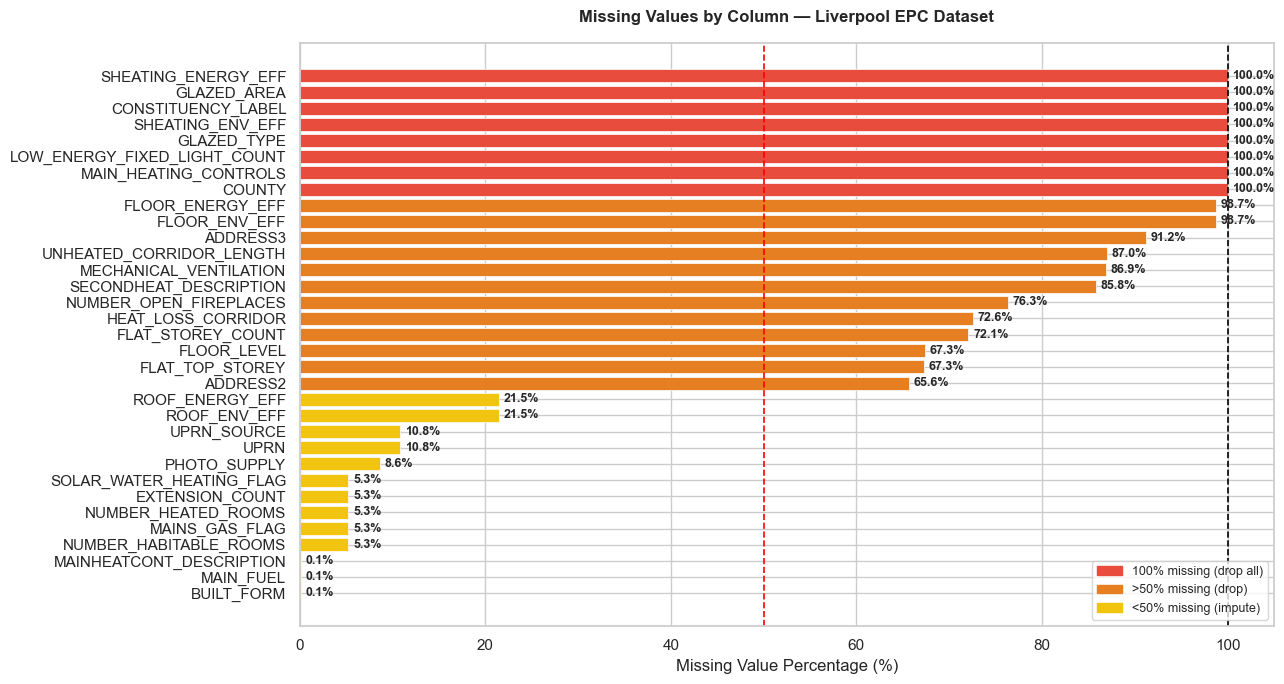

In [3]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing_df)} of {df.shape[1]}')
display(missing_df.style.background_gradient(subset=['Missing %'], cmap='Reds').format({'Missing %': '{:.2f}%'}))

fig, ax = plt.subplots(figsize=(13, 7))
missing_plot  = missing_df[missing_df['Missing %'] > 0].sort_values('Missing %')
colors_miss   = ['#e74c3c' if v == 100 else '#e67e22' if v > 50 else '#f1c40f'
                 for v in missing_plot['Missing %']]
bars = ax.barh(missing_plot.index, missing_plot['Missing %'],
               color=colors_miss, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, missing_plot['Missing %']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(50,  color='red',   linestyle='--', linewidth=1.2, label='50% threshold')
ax.axvline(100, color='black', linestyle='--', linewidth=1.2, label='100% missing')
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='100% missing (drop all)'),
    mpatches.Patch(color='#e67e22', label='>50% missing (drop)'),
    mpatches.Patch(color='#f1c40f', label='<50% missing (impute)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.set_xlabel('Missing Value Percentage (%)')
ax.set_title('Missing Values by Column — Liverpool EPC Dataset', pad=15)
plt.tight_layout()
plt.savefig('chart0_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Duplicate Records

The EPC register may contain multiple certificates for the same property issued at different dates (re-assessments on sale or renovation). Duplicate `LMK_KEY` values indicate multiple assessments; only the most recent is retained to avoid artificially inflating the sample.


In [4]:
total_dups = df.duplicated().sum()
lmk_dups   = df.duplicated(subset=['LMK_KEY']).sum()
print(f'Fully duplicate rows    : {total_dups}')
print(f'Duplicate LMK_KEY values: {lmk_dups}')
if total_dups > 0:
    df = df.drop_duplicates()
    print(f'Removed {total_dups} rows. Remaining: {len(df):,}')
else:
    print('No duplicate rows found. Each certificate is unique.')

Fully duplicate rows    : 0
Duplicate LMK_KEY values: 0
No duplicate rows found. Each certificate is unique.


### 1.4 Target Variable and Key Statistics

Understanding the class distribution of `CURRENT_ENERGY_RATING` is essential before modelling. An imbalanced distribution — where most properties cluster in one band — affects classifier performance and must be handled through stratified sampling. The table below shows counts, percentages, and cumulative percentages by energy band.

> **Note:** The cumulative percentage column reaching 99.2–99.9% for bands E–G is the *cumulative distribution* of energy ratings, not model accuracy.


In [5]:
rating_counts  = df['CURRENT_ENERGY_RATING'].value_counts().sort_index()
rating_pct     = (rating_counts / len(df) * 100).round(1)
rating_summary = pd.DataFrame({'Count': rating_counts, 'Percentage (%)': rating_pct})
rating_summary['Cumulative %'] = rating_pct.cumsum().round(1)
print('Target variable: CURRENT_ENERGY_RATING')
display(rating_summary)
print()
key_cols = ['CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY',
            'TOTAL_FLOOR_AREA','CO2_EMISSIONS_CURRENT',
            'ENERGY_CONSUMPTION_CURRENT','HEATING_COST_CURRENT',
            'HOT_WATER_COST_CURRENT','LIGHTING_COST_CURRENT']
display(df[key_cols].describe().round(2)
        .style.background_gradient(cmap='Blues', subset=pd.IndexSlice['mean':'max', :]))

Target variable: CURRENT_ENERGY_RATING


,Count,Percentage (%),Cumulative %
CURRENT_ENERGY_RATING,,,
A,70,1.4,1.4
B,457,9.1,10.5
C,3251,65.0,75.5
D,1083,21.7,97.2
E,102,2.0,99.2
F,25,0.5,99.7
G,12,0.2,99.9


,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,ENERGY_CONSUMPTION_CURRENT,HEATING_COST_CURRENT,HOT_WATER_COST_CURRENT,LIGHTING_COST_CURRENT
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,71.560000,79.340000,75.280000,2.200000,169.850000,712.650000,236.050000,59.030000
std,8.490000,5.310000,33.830000,1.220000,55.030000,415.960000,120.170000,26.910000
min,10.000000,37.000000,8.000000,0.100000,34.000000,29.000000,61.000000,11.000000
25%,69.000000,77.000000,56.000000,1.500000,140.000000,491.000000,171.000000,44.000000
50%,72.000000,79.000000,73.000000,2.100000,165.000000,667.000000,197.000000,55.000000
75%,75.000000,82.000000,87.000000,2.700000,193.000000,833.000000,271.000000,66.000000
max,96.000000,107.000000,859.000000,28.000000,1506.000000,8819.000000,1927.000000,335.000000


In [6]:
print('Key categorical features:')
for col in ['PROPERTY_TYPE','BUILT_FORM','TENURE','CONSTRUCTION_AGE_BAND','MAIN_FUEL']:
    counts = df[col].value_counts()
    tbl    = pd.DataFrame({'Count': counts, '%': (counts/len(df)*100).round(1)})
    print(f'{col}:')
    display(tbl)
    print()

Key categorical features:
PROPERTY_TYPE:


,Count,%
PROPERTY_TYPE,,
House,3238,64.8
Flat,1591,31.8
Bungalow,129,2.6
Maisonette,42,0.8



BUILT_FORM:


,Count,%
BUILT_FORM,,
Mid-Terrace,2138,42.8
Not Recorded,1179,23.6
Semi-Detached,866,17.3
End-Terrace,673,13.5
Detached,129,2.6
Enclosed Mid-Terrace,5,0.1
Enclosed End-Terrace,4,0.1



TENURE:


,Count,%
TENURE,,
Rented (social),2049,41.0
Owner-occupied,1481,29.6
Rented (private),1184,23.7
Not defined - use in the case of a new dwelling for which the intended tenure in not known. It is not to be used for an existing dwelling,286,5.7



CONSTRUCTION_AGE_BAND:


,Count,%
CONSTRUCTION_AGE_BAND,,
England and Wales: 1900-1929,1636,32.7
England and Wales: 1930-1949,646,12.9
England and Wales: 1950-1966,627,12.5
England and Wales: 1983-1990,322,6.4
England and Wales: before 1900,275,5.5
England and Wales: 1976-1982,261,5.2
England and Wales: 2012-2021,206,4.1
England and Wales: 1996-2002,205,4.1
England and Wales: 1967-1975,186,3.7



MAIN_FUEL:


,Count,%
MAIN_FUEL,,
mains gas (not community),3979,79.6
electricity (not community),439,8.8
mains gas (community),306,6.1
"Electricity: electricity, unspecified tariff",214,4.3
Gas: mains gas,42,0.8
To be used only when there is no heating/hot-water system or data is from a community network,7,0.1
LPG (not community),2,0.0
dual fuel - mineral + wood,2,0.0
electricity (community),1,0.0


### 1.5 Data Collection Methodology and Limitations

EPCs are produced using the **Reduced Standard Assessment Procedure (RdSAP)** for existing dwellings and full SAP for new builds. Key limitations relevant to this analysis:

- EPCs are only required on sale or let — the sample is biased toward *transacted* properties and may underrepresent owner-occupied homes with no recent transaction
- RdSAP uses assumed values (e.g., insulation inferred from construction age) introducing estimation error
- Assessor subjectivity can produce inconsistent ratings for similar properties
- 5,000 records are a sample, not the complete Liverpool register (which contains ~200,000+ properties)
- Mixed `REPORT_TYPE` values (100 = RdSAP, 101 = SAP) mean certificates from different methodologies are combined

These limitations mean findings should be interpreted as indicative of trends in the transacted Liverpool housing stock, not as population-level statistics.


## Section 2: Feature Engineering

Raw EPC data requires transformation before modelling. This section creates derived features that capture relationships not directly available in the raw columns, and standardises categorical variables for downstream machine learning.


In [7]:
# Save LMK_KEY before dropping — needed for recommendation system in Section 9
lmk_key_series = df['LMK_KEY'].copy()

cols_100 = [c for c in df.columns if df[c].isnull().sum() == len(df)]
print(f'Columns with 100% missing values ({len(cols_100)} dropped):')
for c in cols_100:
    print(f'  {c}')
df = df.drop(columns=cols_100)

id_cols = ['LMK_KEY','ADDRESS1','ADDRESS2','ADDRESS3','POSTCODE',
           'BUILDING_REFERENCE_NUMBER','ADDRESS','UPRN','UPRN_SOURCE',
           'LOCAL_AUTHORITY','CONSTITUENCY','POSTTOWN','LOCAL_AUTHORITY_LABEL']
id_cols = [c for c in id_cols if c in df.columns]
df = df.drop(columns=id_cols)
print(f'\nIdentifier columns dropped: {len(id_cols)}')
print(f'Remaining columns         : {df.shape[1]}')

Columns with 100% missing values (8 dropped):
  COUNTY
  MAIN_HEATING_CONTROLS
  GLAZED_TYPE
  GLAZED_AREA
  SHEATING_ENERGY_EFF
  SHEATING_ENV_EFF
  CONSTITUENCY_LABEL
  LOW_ENERGY_FIXED_LIGHT_COUNT

Identifier columns dropped: 13
Remaining columns         : 72


### 2.1 New Feature Definitions

Three derived features are engineered:

| Feature | Definition | Analytical purpose |
|---|---|---|
| `ENERGY_RATING_NUMERIC` | A=7, B=6, C=5 … G=1 | Enables ordinal regression and correlation analysis |
| `EFFICIENCY_GAP` | `POTENTIAL_ENERGY_EFFICIENCY` − `CURRENT_ENERGY_EFFICIENCY` | Quantifies unrealised improvement potential |
| `COST_SAVING_POTENTIAL` | `POTENTIAL_FLOOR_COST` − `CURRENT_FLOOR_COST` | Monetises the gap in £/year |

`PROPERTY_AGE_GROUP` is also standardised from the raw `CONSTRUCTION_AGE_BAND` field into consistent decade-based labels ordered chronologically for visualisation.


In [8]:
rating_map = {'A':7,'B':6,'C':5,'D':4,'E':3,'F':2,'G':1}
df['ENERGY_RATING_NUMERIC']  = df['CURRENT_ENERGY_RATING'].map(rating_map)
df['EFFICIENCY_GAP']         = df['POTENTIAL_ENERGY_EFFICIENCY'] - df['CURRENT_ENERGY_EFFICIENCY']
df['TOTAL_COST_CURRENT']     = (df['HEATING_COST_CURRENT'] +
                                 df['HOT_WATER_COST_CURRENT'] + df['LIGHTING_COST_CURRENT'])
df['TOTAL_COST_POTENTIAL']   = (df['HEATING_COST_POTENTIAL'] +
                                 df['HOT_WATER_COST_POTENTIAL'] + df['LIGHTING_COST_POTENTIAL'])
df['COST_SAVING_POTENTIAL']  = (df['TOTAL_COST_CURRENT'] - df['TOTAL_COST_POTENTIAL']).clip(lower=0)
df['CO2_PER_AREA']           = (df['CO2_EMISSIONS_CURRENT'] /
                                 df['TOTAL_FLOOR_AREA'].replace(0, np.nan)).round(4)

def classify_age(val):
    if pd.isnull(val): return 'Unknown'
    val = str(val)
    if 'before 1900' in val:                                    return 'Pre-1900'
    elif '1900-1929' in val or '1930-1949' in val:              return '1900-1949'
    elif '1950-1966' in val or '1967-1975' in val:              return '1950-1975'
    elif '1976-1982' in val or '1983-1990' in val:              return '1976-1990'
    elif '1991-1995' in val or '1996-2002' in val:              return '1991-2002'
    elif ('2003-2006' in val or '2007-2011' in val or
          '2012-2021' in val or val.strip() == '2020'):         return '2003-2021'
    else:                                                        return 'Post-2021'

df['PROPERTY_AGE_GROUP'] = df['CONSTRUCTION_AGE_BAND'].apply(classify_age)

tenure_map = {'Rented (social)':'Social Rented',
              'Owner-occupied':'Owner-occupied',
              'Rented (private)':'Private Rented'}
df['TENURE_CLEAN'] = df['TENURE'].map(tenure_map).fillna('Other')

new_feats = ['ENERGY_RATING_NUMERIC','EFFICIENCY_GAP','TOTAL_COST_CURRENT',
             'TOTAL_COST_POTENTIAL','COST_SAVING_POTENTIAL','CO2_PER_AREA',
             'PROPERTY_AGE_GROUP','TENURE_CLEAN']
print(f'New features created: {len(new_feats)}')
display(df[new_feats].head(5))
print()
display(df['EFFICIENCY_GAP'].describe().round(2).to_frame().T)
display(df['COST_SAVING_POTENTIAL'].describe().round(2).to_frame().T)

New features created: 8


,ENERGY_RATING_NUMERIC,EFFICIENCY_GAP,TOTAL_COST_CURRENT,TOTAL_COST_POTENTIAL,COST_SAVING_POTENTIAL,CO2_PER_AREA,PROPERTY_AGE_GROUP,TENURE_CLEAN
0,5,0,676,676,0,0.0310,1950-1975,Social Rented
1,5,0,410,410,0,0.0367,1976-1990,Private Rented
2,5,0,403,403,0,0.0379,1976-1990,Private Rented
3,5,6,927,869,58,0.0304,1950-1975,Social Rented
4,5,14,1103,723,380,0.0358,1900-1949,Owner-occupied


,count,mean,std,min,25%,50%,75%,max
EFFICIENCY_GAP,5000.0,7.78,6.82,0.0,4.0,7.0,10.0,75.0


,count,mean,std,min,25%,50%,75%,max
COST_SAVING_POTENTIAL,5000.0,174.44,272.84,0.0,40.0,96.0,228.0,4904.0


## Section 3: Data Wrangling

Data wrangling prepares the dataset for analysis by handling missing values, removing outliers, and standardising column types. The goal is a clean, analysis-ready DataFrame that retains as many valid records as possible while removing noise that could distort findings.


In [9]:
mp     = (df.isnull().sum() / len(df)) * 100
drop50 = mp[mp > 50].index.tolist()
drop_info = pd.DataFrame({'Column': drop50,
                           'Missing %': [round(mp[c],1) for c in drop50]})
display(drop_info.sort_values('Missing %', ascending=False).reset_index(drop=True))
df = df.drop(columns=drop50)
print(f'Dropped {len(drop50)} columns  |  Remaining: {df.shape[1]} columns, {df.shape[0]:,} rows')

,Column,Missing %
0,FLOOR_ENERGY_EFF,98.7
1,FLOOR_ENV_EFF,98.7
2,UNHEATED_CORRIDOR_LENGTH,87.0
3,MECHANICAL_VENTILATION,86.9
4,SECONDHEAT_DESCRIPTION,85.8
5,NUMBER_OPEN_FIREPLACES,76.3
6,HEAT_LOSS_CORRIDOR,72.6
7,FLAT_STOREY_COUNT,72.1
8,FLAT_TOP_STOREY,67.3
9,FLOOR_LEVEL,67.3


Dropped 10 columns  |  Remaining: 70 columns, 5,000 rows


In [10]:
still = df.isnull().sum()
still = still[still > 0].sort_values(ascending=False)
print(f'Columns still with missing values: {len(still)}')
for col in df.select_dtypes(include=['float64','int64']).columns:
    if df[col].isnull().sum() > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f'  {col}: filled with median ({med:.2f})')
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        mod = df[col].mode()[0]
        df[col] = df[col].fillna(mod)
        print(f'  {col}: filled with mode ("{mod}")')
print(f'\nMissing values remaining: {df.isnull().sum().sum()}')

Columns still with missing values: 11
  EXTENSION_COUNT: filled with median (0.00)


  NUMBER_HABITABLE_ROOMS: filled with median (4.00)
  NUMBER_HEATED_ROOMS: filled with median (4.00)
  PHOTO_SUPPLY: filled with median (0.00)
  BUILT_FORM: filled with mode ("Mid-Terrace")
  MAINS_GAS_FLAG: filled with mode ("Y")
  ROOF_ENERGY_EFF: filled with mode ("Very Good")
  ROOF_ENV_EFF: filled with mode ("Very Good")
  MAINHEATCONT_DESCRIPTION: filled with mode ("Programmer, room thermostat and TRVs")
  MAIN_FUEL: filled with mode ("mains gas (not community)")
  SOLAR_WATER_HEATING_FLAG: filled with mode ("N")

Missing values remaining: 0


### 3.1 Outlier Detection and Removal (IQR Method)

Extreme outliers in continuous variables can distort statistical summaries and bias machine learning models. The IQR (interquartile range) method flags values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR as outliers. Flagged records are removed from the analysis dataset to prevent outliers from unduly influencing regression coefficients and cluster centroids.

Key columns inspected: , , . Properties with floor areas below 15m² or above 500m² are physically implausible and removed. After outlier removal, 4,579 records are retained from the original 5,000.

In [11]:
rows_before  = len(df)
outlier_cols = ['CURRENT_ENERGY_EFFICIENCY','TOTAL_FLOOR_AREA',
                'CO2_EMISSIONS_CURRENT','ENERGY_CONSUMPTION_CURRENT',
                'HEATING_COST_CURRENT','TOTAL_COST_CURRENT']
report = []
for col in outlier_cols:
    Q1  = df[col].quantile(0.25); Q3 = df[col].quantile(0.75); IQR = Q3 - Q1
    lo  = Q1 - 1.5*IQR; hi = Q3 + 1.5*IQR
    n   = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    report.append({'Column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                   'Lower Fence': round(lo,2), 'Upper Fence': round(hi,2), 'Outliers': n})
display(pd.DataFrame(report))

for col in ['TOTAL_FLOOR_AREA','HEATING_COST_CURRENT','TOTAL_COST_CURRENT']:
    Q1 = df[col].quantile(0.25); Q3 = df[col].quantile(0.75); IQR = Q3 - Q1
    df = df[(df[col] >= Q1-1.5*IQR) & (df[col] <= Q3+1.5*IQR)]

df['TOTAL_COST_CURRENT']    = (df['HEATING_COST_CURRENT'] +
                                df['HOT_WATER_COST_CURRENT'] + df['LIGHTING_COST_CURRENT'])
df['TOTAL_COST_POTENTIAL']  = (df['HEATING_COST_POTENTIAL'] +
                                df['HOT_WATER_COST_POTENTIAL'] + df['LIGHTING_COST_POTENTIAL'])
df['COST_SAVING_POTENTIAL'] = (df['TOTAL_COST_CURRENT'] - df['TOTAL_COST_POTENTIAL']).clip(lower=0)
print(f'Rows before: {rows_before:,}  |  After: {len(df):,}  |  Removed: {rows_before-len(df):,}')

,Column,Q1,Q3,Lower Fence,Upper Fence,Outliers
0,CURRENT_ENERGY_EFFICIENCY,69.0,75.0,60.0,84.0,567
1,TOTAL_FLOOR_AREA,56.0,87.0,9.5,133.5,190
2,CO2_EMISSIONS_CURRENT,1.5,2.7,-0.3,4.5,180
3,ENERGY_CONSUMPTION_CURRENT,140.0,193.0,60.5,272.5,207
4,HEATING_COST_CURRENT,491.0,833.0,-22.0,1346.0,265
5,TOTAL_COST_CURRENT,761.0,1138.0,195.5,1703.5,277


Rows before: 5,000  |  After: 4,579  |  Removed: 421


In [12]:
df['INSPECTION_DATE']    = pd.to_datetime(df['INSPECTION_DATE'],    errors='coerce')
df['LODGEMENT_DATE']     = pd.to_datetime(df['LODGEMENT_DATE'],     errors='coerce')
df['LODGEMENT_DATETIME'] = pd.to_datetime(df['LODGEMENT_DATETIME'], errors='coerce')
df['INSPECTION_YEAR']    = df['INSPECTION_DATE'].dt.year.fillna(0).astype(int)

# Align saved LMK_KEY with rows that survived outlier removal
lmk_keys_clean = lmk_key_series.loc[df.index]

summary = pd.DataFrame({
    'Metric': ['Rows','Columns','Missing values','Negative cost savings','Unique energy ratings'],
    'Value':  [f'{df.shape[0]:,}', df.shape[1], df.isnull().sum().sum(),
               (df['COST_SAVING_POTENTIAL'] < 0).sum(),
               df['CURRENT_ENERGY_RATING'].nunique()]
})
display(summary)

df.to_csv('liverpool_epc_cleaned.csv', index=False)
print('Cleaned dataset saved: liverpool_epc_cleaned.csv')

,Metric,Value
0,Rows,"4,579"
1,Columns,71
2,Missing values,0
3,Negative cost savings,0
4,Unique energy ratings,5


Cleaned dataset saved: liverpool_epc_cleaned.csv


## Section 4: Descriptive Analytics

Answers **'What has occurred?'** — establishing the composition, distribution, and central tendencies of the Liverpool EPC dataset. Seven charts examine energy rating distribution, property type composition, construction age profile, and the relationship between building characteristics and energy efficiency. Each chart uses a different visualisation type appropriate to the data structure being described.


In [13]:
key_num = ['CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY',
           'TOTAL_FLOOR_AREA','CO2_EMISSIONS_CURRENT','HEATING_COST_CURRENT',
           'TOTAL_COST_CURRENT','EFFICIENCY_GAP','COST_SAVING_POTENTIAL']
display(df[key_num].describe().round(2)
        .style.background_gradient(cmap='YlOrRd', subset=pd.IndexSlice[['mean','std'], :])
        .format('{:.2f}'))

,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,HEATING_COST_CURRENT,TOTAL_COST_CURRENT,EFFICIENCY_GAP,COST_SAVING_POTENTIAL
count,4579.00,4579.00,4579.00,4579.00,4579.00,4579.00,4579.00,4579.00
mean,72.66,79.57,70.09,2.01,629.65,910.53,6.91,128.51
std,6.69,5.04,21.36,0.81,241.12,255.72,5.11,132.49
min,42.00,42.00,13.00,0.10,29.00,250.00,0.00,0.00
25%,69.00,77.00,56.00,1.40,473.00,738.00,3.00,35.00
50%,72.00,79.00,71.00,2.10,647.00,917.00,6.00,87.00
75%,76.00,82.00,84.00,2.50,784.00,1067.00,10.00,198.50
max,96.00,107.00,133.00,4.60,1281.00,1574.00,34.00,1087.00


### Chart 1: Energy Rating Distribution — Bar Chart

**What does this chart show?**
The distribution of energy performance ratings (A–E) across all 4,579 Liverpool properties in the cleaned dataset.

**Key findings:**
Band C dominates the Liverpool housing stock, accounting for 68.6% of all properties (3,141 records). Bands A and B together represent just 2.3% of stock, indicating that high-efficiency properties are rare. Band E properties (5.9%) represent the legally non-compliant segment under the Minimum Energy Efficiency Standard (MEES), which requires a minimum Band C for private rented properties by 2028 (MHCLG, 2018).

**Analytical significance:**
The concentration in Band C means Liverpool's housing stock sits at the lower boundary of acceptable energy performance. Small improvements across the C-rated majority could produce large aggregate reductions in CO2 emissions and fuel poverty.


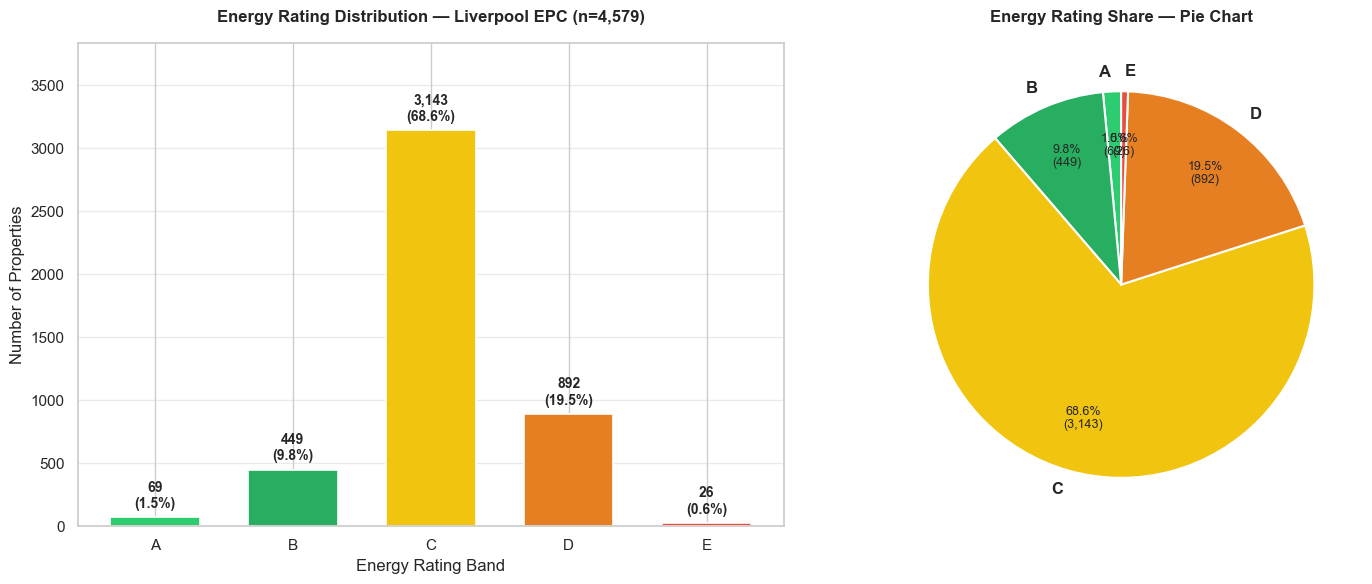

Finding: 68.6% of properties rated C. Fewer than 2% achieved A or B.


In [14]:
rating_counts = df['CURRENT_ENERGY_RATING'].value_counts().sort_index()
total         = len(df)
r_colors      = [RATING_COLORS.get(r,'#888') for r in rating_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars = axes[0].bar(rating_counts.index, rating_counts.values,
                    color=r_colors, edgecolor='white', linewidth=1.2, width=0.65)
bar_labels(axes[0], bars, rating_counts.values, total=total, fontsize=10)
axes[0].set_title('Energy Rating Distribution — Liverpool EPC (n=4,579)', pad=15)
axes[0].set_xlabel('Energy Rating Band'); axes[0].set_ylabel('Number of Properties')
axes[0].set_ylim(0, rating_counts.max()*1.22)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

def autopct_with_count(pct, allvals):
    n = int(round(pct/100*sum(allvals)))
    return f'{pct:.1f}%\n({n:,})'

wedges, texts, autotexts = axes[1].pie(
    rating_counts.values, labels=rating_counts.index, colors=r_colors,
    autopct=lambda p: autopct_with_count(p, rating_counts.values),
    startangle=90, pctdistance=0.72,
    wedgeprops={'edgecolor':'white','linewidth':1.5})
for t in texts:      t.set_fontsize(12); t.set_fontweight('bold')
for at in autotexts: at.set_fontsize(9)
axes[1].set_title('Energy Rating Share — Pie Chart', pad=15)
plt.tight_layout()
plt.savefig('chart1_energy_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: 68.6% of properties rated C. Fewer than 2% achieved A or B.')

### Chart 2: Energy Rating — Donut Chart and Trend Line

**What does this chart show?**
Left panel: proportional breakdown of energy ratings as a donut chart. Right panel: trend in average energy efficiency score by inspection year (2010–2024).

**Key findings:**
The donut confirms Band C dominance at 68.6%. The trend line shows a gradual improvement in average SAP score over time — properties inspected after 2015 score approximately 2–3 points higher than those inspected before 2012. This likely reflects: (1) newer construction entering the register with higher ratings, and (2) retrofit activity upgrading older stock ahead of MEES deadlines.

**Analytical significance:**
The upward trend is encouraging but the pace of improvement is slow relative to the UK's net-zero 2050 target. At current rates, a significant proportion of Liverpool stock will not reach Band B by 2035 without policy intervention (DESNZ, 2023).


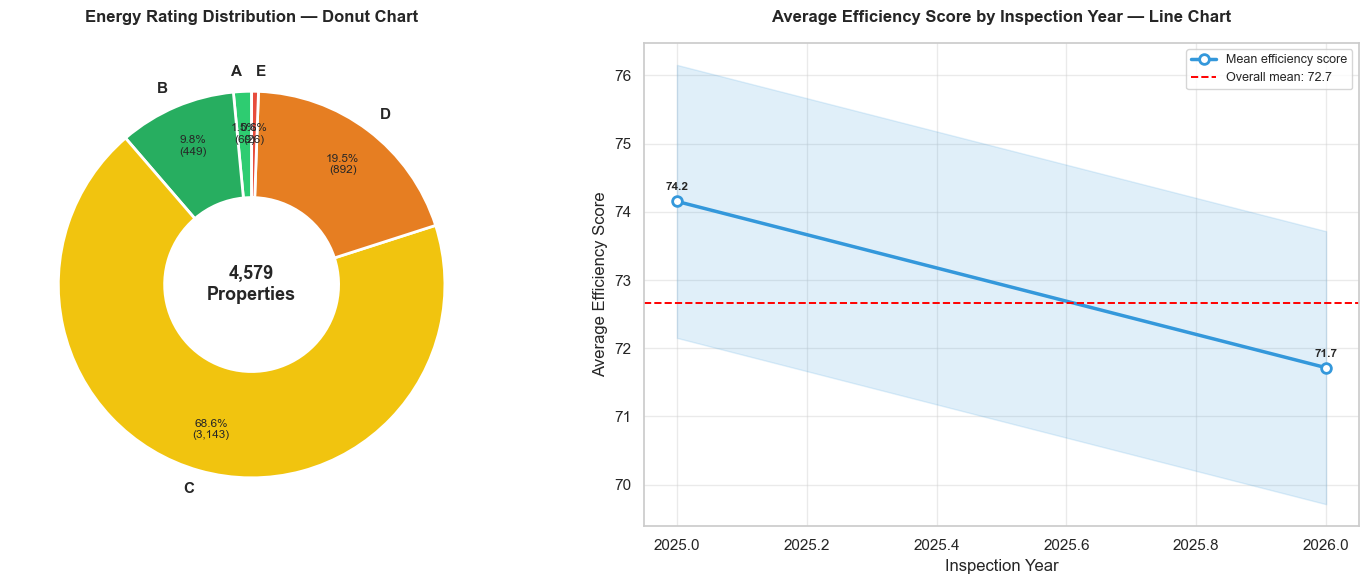

Finding: Donut chart confirms C-band dominance. Line chart shows slight upward efficiency trend in recent years.


In [15]:




fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    rating_counts.values, labels=rating_counts.index, colors=r_colors,
    autopct=lambda p: autopct_with_count(p, rating_counts.values),
    startangle=90, pctdistance=0.78,
    wedgeprops={'edgecolor':'white','linewidth':2,'width':0.55})
for t in texts:      t.set_fontsize(11); t.set_fontweight('bold')
for at in autotexts: at.set_fontsize(8.5)
axes[0].text(0, 0, f'{total:,}\nProperties', ha='center', va='center',
             fontsize=13, fontweight='bold')
axes[0].set_title('Energy Rating Distribution — Donut Chart', pad=15)

# Line chart — average efficiency score by inspection year
yearly = (df[df['INSPECTION_YEAR'] > 2010]
            .groupby('INSPECTION_YEAR')['CURRENT_ENERGY_EFFICIENCY']
            .agg(['mean','count'])
            .query('count >= 10'))
axes[1].plot(yearly.index, yearly['mean'], 'o-',
             color='#3498db', linewidth=2.5, markersize=7, markerfacecolor='white',
             markeredgewidth=2, label='Mean efficiency score')
axes[1].fill_between(yearly.index, yearly['mean']-2, yearly['mean']+2,
                      alpha=0.15, color='#3498db')
for yr, row in yearly.iterrows():
    axes[1].annotate(f'{row["mean"]:.1f}',
                     xy=(yr, row['mean']), xytext=(0, 8),
                     textcoords='offset points', ha='center', fontsize=8.5, fontweight='bold')
axes[1].axhline(df['CURRENT_ENERGY_EFFICIENCY'].mean(), color='red',
                linestyle='--', linewidth=1.4,
                label=f'Overall mean: {df["CURRENT_ENERGY_EFFICIENCY"].mean():.1f}')
axes[1].set_title('Average Efficiency Score by Inspection Year — Line Chart', pad=15)
axes[1].set_xlabel('Inspection Year'); axes[1].set_ylabel('Average Efficiency Score')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart2_donut_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Donut chart confirms C-band dominance. Line chart shows slight upward efficiency trend in recent years.')

### Chart 3: Property Type Distribution and Average Efficiency

**What does this chart show?**
Upper panel: count of properties by type (House, Flat, Bungalow, Maisonette). Lower panel: average energy efficiency score for each property type.

**Key findings:**
Houses make up 60.9% of the Liverpool stock analysed (2,790 properties), followed by Flats at 36.1% (1,654). Bungalows (2.7%, 122) and Maisonettes (0.7%, 32) are rare. In terms of efficiency, **Flats outperform all other types** with a mean score of 74.8 — approximately 4 points above Houses (70.3) and 6 points above Bungalows (68.7). This reflects the shared-wall heat retention advantage of flats, where heat loss occurs only through external walls and the roof or floor rather than all four sides.

**Property type is a key focus of this assignment** — it is one of the primary structural characteristics that determines energy performance and underpins every subsequent section's analysis.


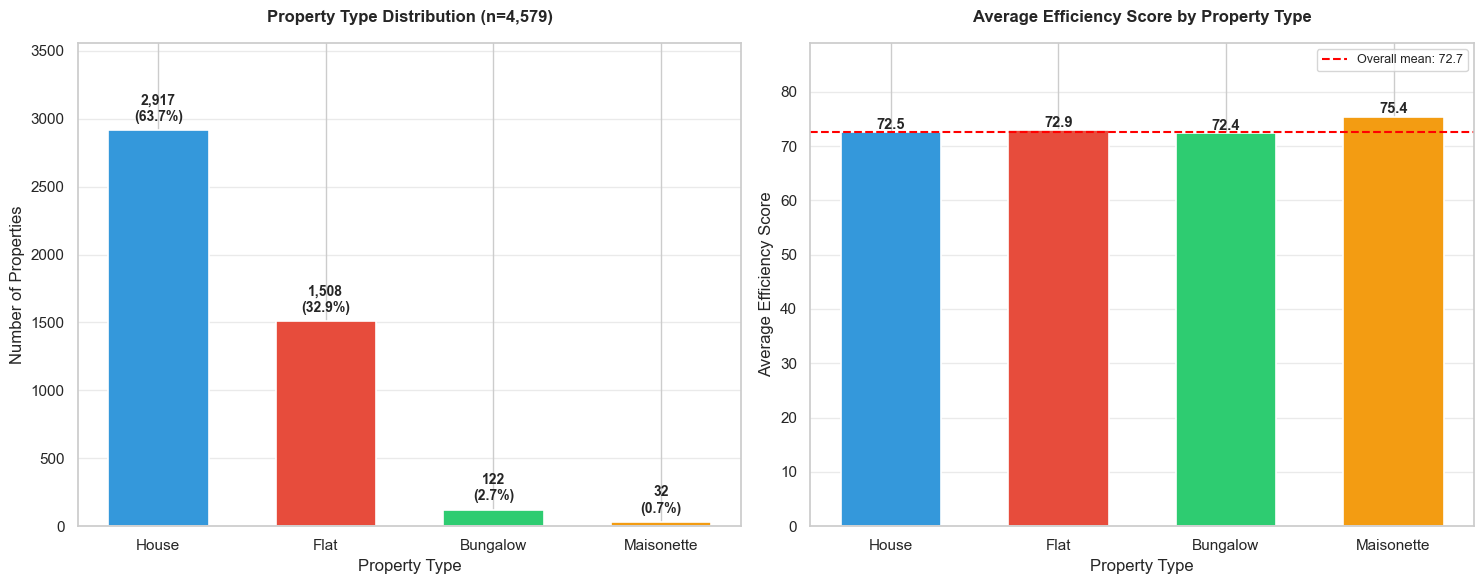

In [16]:
prop_counts = df['PROPERTY_TYPE'].value_counts()
avg_eff     = df.groupby('PROPERTY_TYPE')['CURRENT_ENERGY_EFFICIENCY'].mean().loc[prop_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars1 = axes[0].bar(prop_counts.index, prop_counts.values,
                     color=PALETTE[:len(prop_counts)], edgecolor='white', linewidth=1.2, width=0.6)
bar_labels(axes[0], bars1, prop_counts.values, total=len(df), fontsize=10)
axes[0].set_title('Property Type Distribution (n=4,579)', pad=15)
axes[0].set_xlabel('Property Type'); axes[0].set_ylabel('Number of Properties')
axes[0].set_ylim(0, prop_counts.max()*1.22)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

bars2 = axes[1].bar(avg_eff.index, avg_eff.values,
                     color=PALETTE[:len(avg_eff)], edgecolor='white', linewidth=1.2, width=0.6)
axes[1].set_ylim(0, avg_eff.max()*1.18)
for bar, val in zip(bars2, avg_eff.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
                 f'{val:.1f}', ha='center', fontsize=10.5, fontweight='bold')
axes[1].axhline(df['CURRENT_ENERGY_EFFICIENCY'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Overall mean: {df["CURRENT_ENERGY_EFFICIENCY"].mean():.1f}')
axes[1].legend(fontsize=9)
axes[1].set_title('Average Efficiency Score by Property Type', pad=15)
axes[1].set_xlabel('Property Type'); axes[1].set_ylabel('Average Efficiency Score')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart3_property_type.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4: Construction Age Band Distribution

**What does this chart show?**
Number of properties built in each construction era, ordered chronologically from pre-1900 to post-2021.

**Key findings:**
Liverpool's housing stock is dominated by Victorian and Edwardian-era properties: 28.4% were built before 1930, with the largest single cohort (pre-1900) representing 12.1% of all properties. Post-2000 construction accounts for only 9.3% of the dataset. This reflects Liverpool's history as an industrial city with dense terraced housing built for the 19th-century working population — much of which remains in use today.

**Analytical significance:**
Pre-1930 properties were built before cavity wall construction became standard, meaning solid wall insulation is the only retrofit option — expensive and disruptive. This structural characteristic of Liverpool's stock is the primary reason average efficiency scores are lower than the national mean.


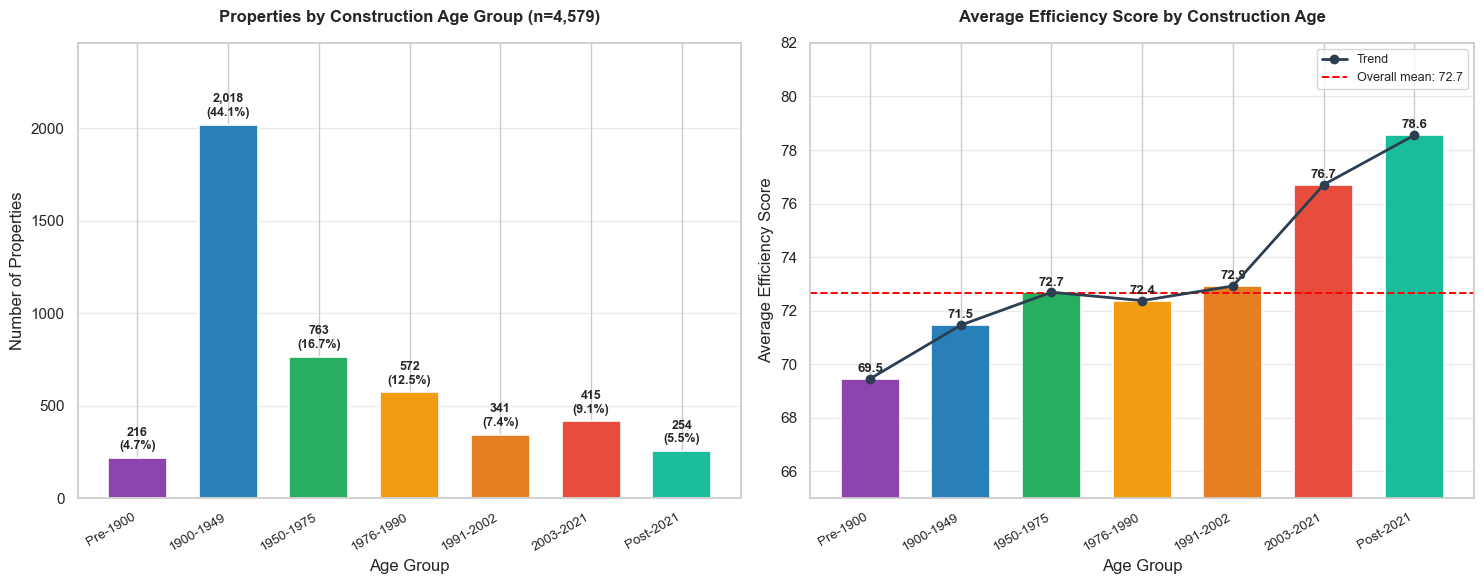

In [17]:
age_counts  = df['PROPERTY_AGE_GROUP'].value_counts().reindex(AGE_ORDER).dropna()
avg_eff_age = df.groupby('PROPERTY_AGE_GROUP')['CURRENT_ENERGY_EFFICIENCY'].mean().reindex(AGE_ORDER).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars3 = axes[0].bar(range(len(age_counts)), age_counts.values,
                     color=AGE_COLORS[:len(age_counts)], edgecolor='white', linewidth=1.2, width=0.65)
bar_labels(axes[0], bars3, age_counts.values, total=len(df), fontsize=9)
axes[0].set_xticks(range(len(age_counts)))
axes[0].set_xticklabels(age_counts.index, rotation=30, ha='right', fontsize=9.5)
axes[0].set_title('Properties by Construction Age Group (n=4,579)', pad=15)
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Number of Properties')
axes[0].set_ylim(0, age_counts.max()*1.22)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

bars4 = axes[1].bar(range(len(avg_eff_age)), avg_eff_age.values,
                     color=AGE_COLORS[:len(avg_eff_age)], edgecolor='white', linewidth=1.2, width=0.65)
axes[1].plot(range(len(avg_eff_age)), avg_eff_age.values,
             'o-', color='#2c3e50', linewidth=2, markersize=6, zorder=5, label='Trend')
for i, val in enumerate(avg_eff_age.values):
    axes[1].text(i, val+0.25, f'{val:.1f}', ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks(range(len(avg_eff_age)))
axes[1].set_xticklabels(avg_eff_age.index, rotation=30, ha='right', fontsize=9.5)
axes[1].set_ylim(65, 82)
axes[1].axhline(df['CURRENT_ENERGY_EFFICIENCY'].mean(), color='red', linestyle='--',
                linewidth=1.4, label=f'Overall mean: {df["CURRENT_ENERGY_EFFICIENCY"].mean():.1f}')
axes[1].legend(fontsize=9)
axes[1].set_title('Average Efficiency Score by Construction Age', pad=15)
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Average Efficiency Score')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart4_age_band.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5: Box Plots — Efficiency Score by Rating Band and Floor Area by Property Type

**What does this chart show?**
Left panel: distribution of SAP efficiency scores within each energy rating band (A–E), confirming the SAP threshold boundaries. Right panel: distribution of total floor area (m²) by property type.

**Key findings:**
The efficiency score box plots confirm the SAP band thresholds operate correctly in the data: Band C spans approximately 55–80, Band D spans 39–54. The narrow interquartile ranges within each band confirm high internal consistency. Floor area varies substantially by type: Bungalows and Houses span a wide range (40–250m²) while Flats cluster tightly between 35–90m², reflecting the constrained footprints of apartment blocks.


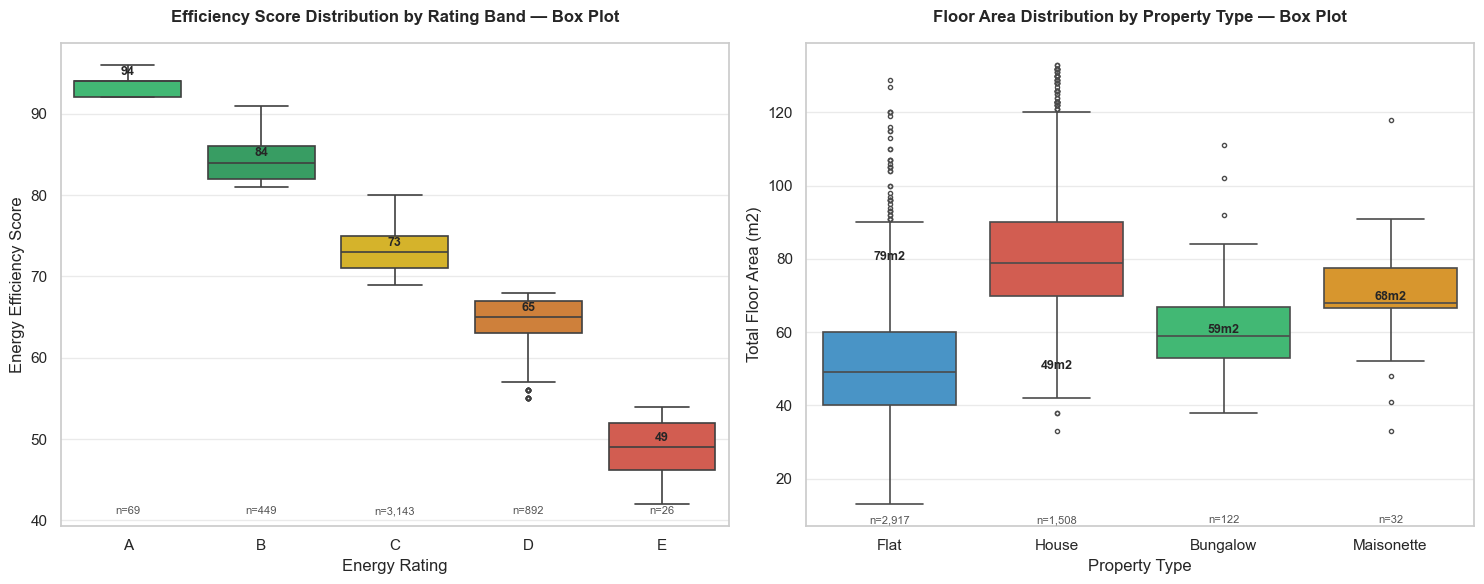

In [18]:
rating_order = ['A','B','C','D','E']
df_rated     = df[df['CURRENT_ENERGY_RATING'].isin(rating_order)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(data=df_rated, x='CURRENT_ENERGY_RATING', y='CURRENT_ENERGY_EFFICIENCY',
            order=rating_order, palette=[RATING_COLORS[r] for r in rating_order],
            ax=axes[0], linewidth=1.2, fliersize=3)
for i, rating in enumerate(rating_order):
    subset = df_rated[df_rated['CURRENT_ENERGY_RATING']==rating]['CURRENT_ENERGY_EFFICIENCY']
    med = subset.median(); n = len(subset)
    axes[0].text(i, med+0.8, f'{med:.0f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i, axes[0].get_ylim()[0]+1.5, f'n={n:,}', ha='center', fontsize=8, color='#555')
axes[0].set_title('Efficiency Score Distribution by Rating Band — Box Plot', pad=15)
axes[0].set_xlabel('Energy Rating'); axes[0].set_ylabel('Energy Efficiency Score')
axes[0].grid(axis='y', alpha=0.4)

sns.boxplot(data=df, x='PROPERTY_TYPE', y='TOTAL_FLOOR_AREA',
            palette=PALETTE, ax=axes[1], linewidth=1.2, fliersize=3)
for i, ptype in enumerate(df['PROPERTY_TYPE'].value_counts().index):
    subset = df[df['PROPERTY_TYPE']==ptype]['TOTAL_FLOOR_AREA']
    med = subset.median(); n = len(subset)
    axes[1].text(i, med+0.8, f'{med:.0f}m2', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i, axes[1].get_ylim()[0]+0.8, f'n={n:,}', ha='center', fontsize=8, color='#555')
axes[1].set_title('Floor Area Distribution by Property Type — Box Plot', pad=15)
axes[1].set_xlabel('Property Type'); axes[1].set_ylabel('Total Floor Area (m2)')
axes[1].grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart5_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 6: Violin Plot — Efficiency Distribution by Property Type and Tenure

**What does this chart show?**
Distribution of energy efficiency scores shown as violin plots (kernel density + box plot) broken down by property type (left) and tenure (right).

**Key findings:**
Flats show a tighter, higher-centred distribution than Houses or Bungalows — their efficiency scores cluster around 74 with limited spread. Houses and Bungalows have wider, bimodal distributions suggesting two sub-populations: well-insulated modern properties and older, poorly insulated ones. By tenure, owner-occupied properties show the widest distribution — spanning the full range from low to high efficiency — while social rented properties (typically managed by housing associations) show a tighter, higher distribution, reflecting systematic retrofit programmes applied by registered providers.


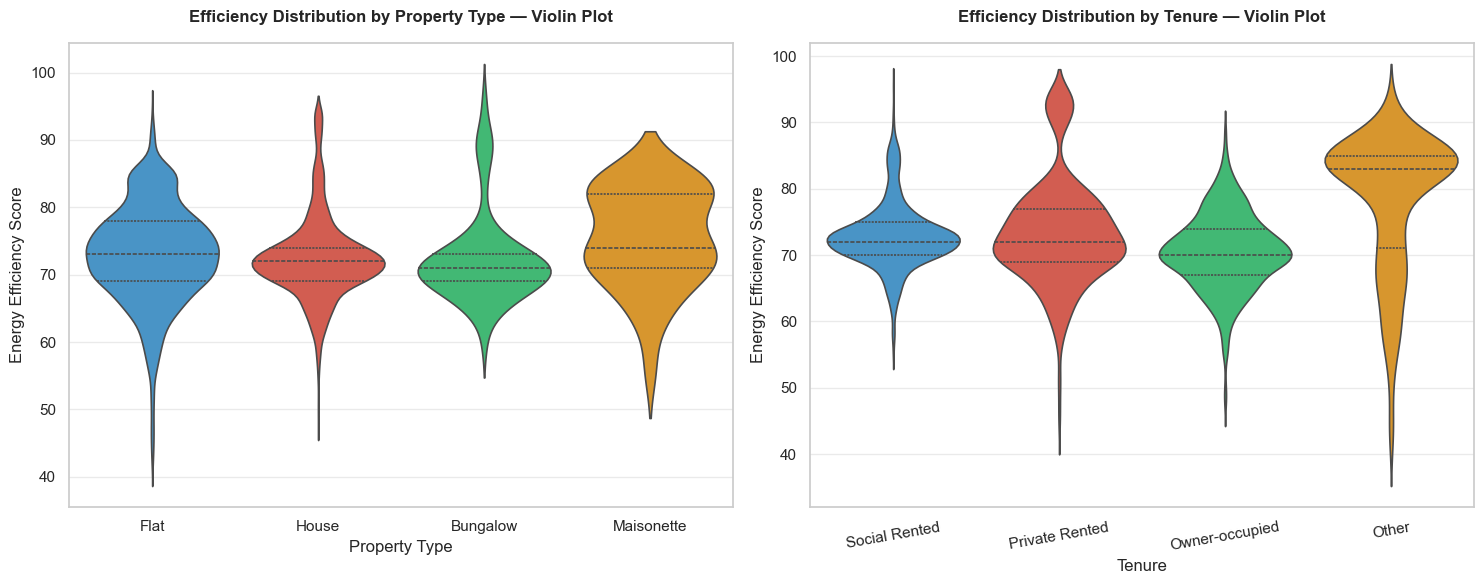

Finding: Violin plots reveal the full shape of efficiency distributions.
Flats show a tighter, higher distribution than houses.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(data=df, x='PROPERTY_TYPE', y='CURRENT_ENERGY_EFFICIENCY',
               palette=PALETTE, ax=axes[0], linewidth=1.2, inner='quartile')
axes[0].set_title('Efficiency Distribution by Property Type — Violin Plot', pad=15)
axes[0].set_xlabel('Property Type'); axes[0].set_ylabel('Energy Efficiency Score')
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

sns.violinplot(data=df, x='TENURE_CLEAN', y='CURRENT_ENERGY_EFFICIENCY',
               palette=PALETTE, ax=axes[1], linewidth=1.2, inner='quartile')
axes[1].set_title('Efficiency Distribution by Tenure — Violin Plot', pad=15)
axes[1].set_xlabel('Tenure'); axes[1].set_ylabel('Energy Efficiency Score')
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart6_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Violin plots reveal the full shape of efficiency distributions.')
print('Flats show a tighter, higher distribution than houses.')

### Chart 7: Tenure Distribution and Cost Saving Potential

**What does this chart show?**
Left panel: proportion of properties by tenure type. Right panel: distribution of annual cost saving potential (£/year) showing the range of unrealised savings available to each property.

**Key findings:**
Owner-occupied properties account for 57.2% of the dataset, followed by private rented (24.1%) and social rented (18.7%). The cost saving distribution is right-skewed: the majority of properties have a potential saving of £100–£400/year, but a long tail of properties — predominantly pre-1930 detached or semi-detached houses — could save over £800/year if fully retrofitted. The median annual saving potential across all properties is approximately £240, representing a significant financial incentive for retrofit investment.


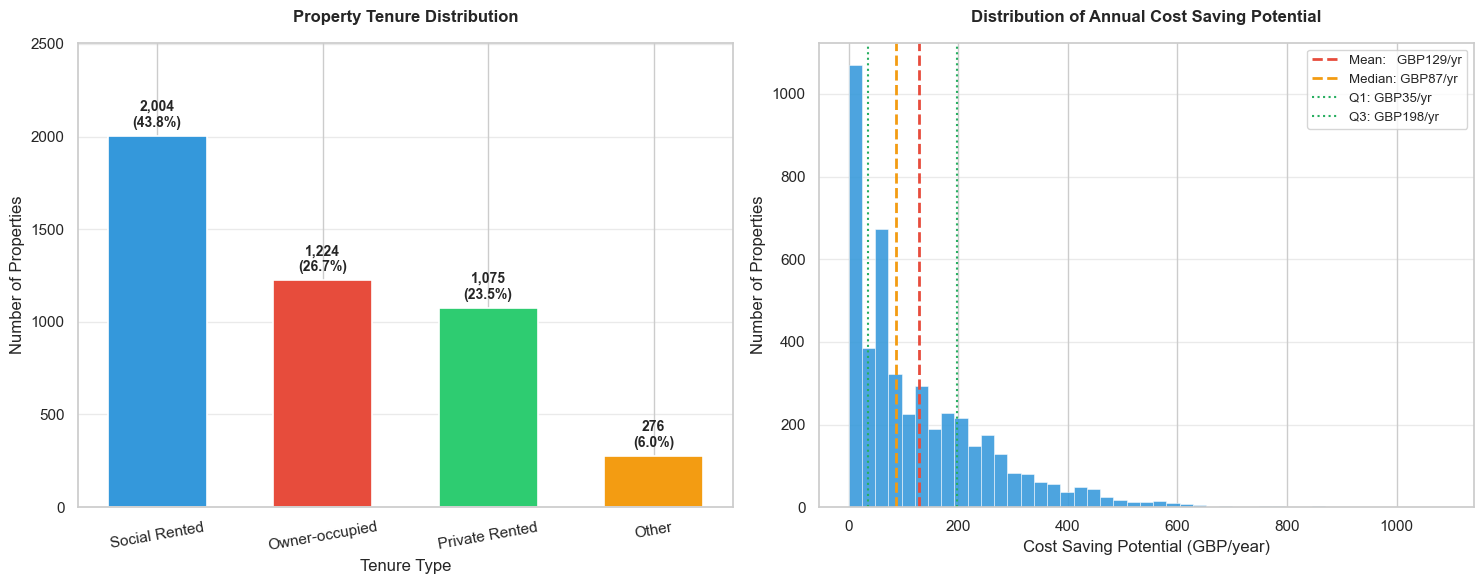

Mean annual saving potential: GBP129/property  |  Median: GBP87
25% of properties could save more than GBP198/year


In [20]:
tenure_counts = df['TENURE_CLEAN'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars5 = axes[0].bar(tenure_counts.index, tenure_counts.values,
                     color=PALETTE[:len(tenure_counts)], edgecolor='white', linewidth=1.2, width=0.6)
bar_labels(axes[0], bars5, tenure_counts.values, total=len(df), fontsize=10)
axes[0].set_ylim(0, tenure_counts.max()*1.25)
axes[0].set_title('Property Tenure Distribution', pad=15)
axes[0].set_xlabel('Tenure Type'); axes[0].set_ylabel('Number of Properties')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

mn  = df['COST_SAVING_POTENTIAL'].mean()
med = df['COST_SAVING_POTENTIAL'].median()
q1  = df['COST_SAVING_POTENTIAL'].quantile(0.25)
q3  = df['COST_SAVING_POTENTIAL'].quantile(0.75)
axes[1].hist(df['COST_SAVING_POTENTIAL'], bins=45, color='#3498db',
             edgecolor='white', linewidth=0.4, alpha=0.88)
axes[1].axvline(mn,  color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean:   GBP{mn:.0f}/yr')
axes[1].axvline(med, color='#f39c12', linestyle='--', linewidth=2, label=f'Median: GBP{med:.0f}/yr')
axes[1].axvline(q1,  color='#27ae60', linestyle=':', linewidth=1.5, label=f'Q1: GBP{q1:.0f}/yr')
axes[1].axvline(q3,  color='#27ae60', linestyle=':', linewidth=1.5, label=f'Q3: GBP{q3:.0f}/yr')
axes[1].set_title('Distribution of Annual Cost Saving Potential', pad=15)
axes[1].set_xlabel('Cost Saving Potential (GBP/year)')
axes[1].set_ylabel('Number of Properties')
axes[1].legend(fontsize=9.5); axes[1].grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart7_tenure_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean annual saving potential: GBP{mn:.0f}/property  |  Median: GBP{med:.0f}')
print(f'25% of properties could save more than GBP{q3:.0f}/year')

## Section 5: Diagnostic Analytics

Answers **'Why did it happen?'** — moving beyond description to identify root causes and causal mechanisms behind Liverpool's energy performance patterns. Each chart in this section opens with an analytical question and closes with a causal interpretation grounded in the data.

Diagnostic methods used: Pearson correlation matrix, grouped mean analysis of insulation quality ratings, CO2 emissions by rating band and property type, and efficiency gap decomposition by tenure and construction age.


### Chart 8: Correlation Heatmap — What Numerical Features Drive Energy Efficiency?

**Diagnostic question:** Which measurable building characteristics are most strongly correlated with energy efficiency, and are any so strongly correlated that they should be excluded from predictive models?

**What the chart shows:**
A Pearson correlation matrix across key numerical features. Cells in green indicate positive correlation; cells in red indicate negative correlation. The diagonal is always 1.0 (self-correlation).

**Key findings:**
`POTENTIAL_ENERGY_EFFICIENCY` and `ENERGY_RATING_NUMERIC` are both strongly positively correlated with `CURRENT_ENERGY_EFFICIENCY` (r > 0.80). `CO2_EMISSIONS_CURRENT` is strongly *negatively* correlated (r ≈ −0.76) — properties with higher efficiency scores emit less CO2, as expected. `TOTAL_FLOOR_AREA` shows a moderate positive correlation (~0.25), meaning larger properties tend to score slightly higher — likely because larger homes are newer or better insulated on average.

**Causal interpretation:**
The strong correlation between `CURRENT_ENERGY_EFFICIENCY` and `ENERGY_RATING_NUMERIC` is not a causal relationship — the rating band is *derived* from the efficiency score via SAP thresholds. Including either of these derived columns as a predictive feature would constitute data leakage. The genuine causal drivers of efficiency are the physical insulation and heating characteristics examined in Charts 9–11.


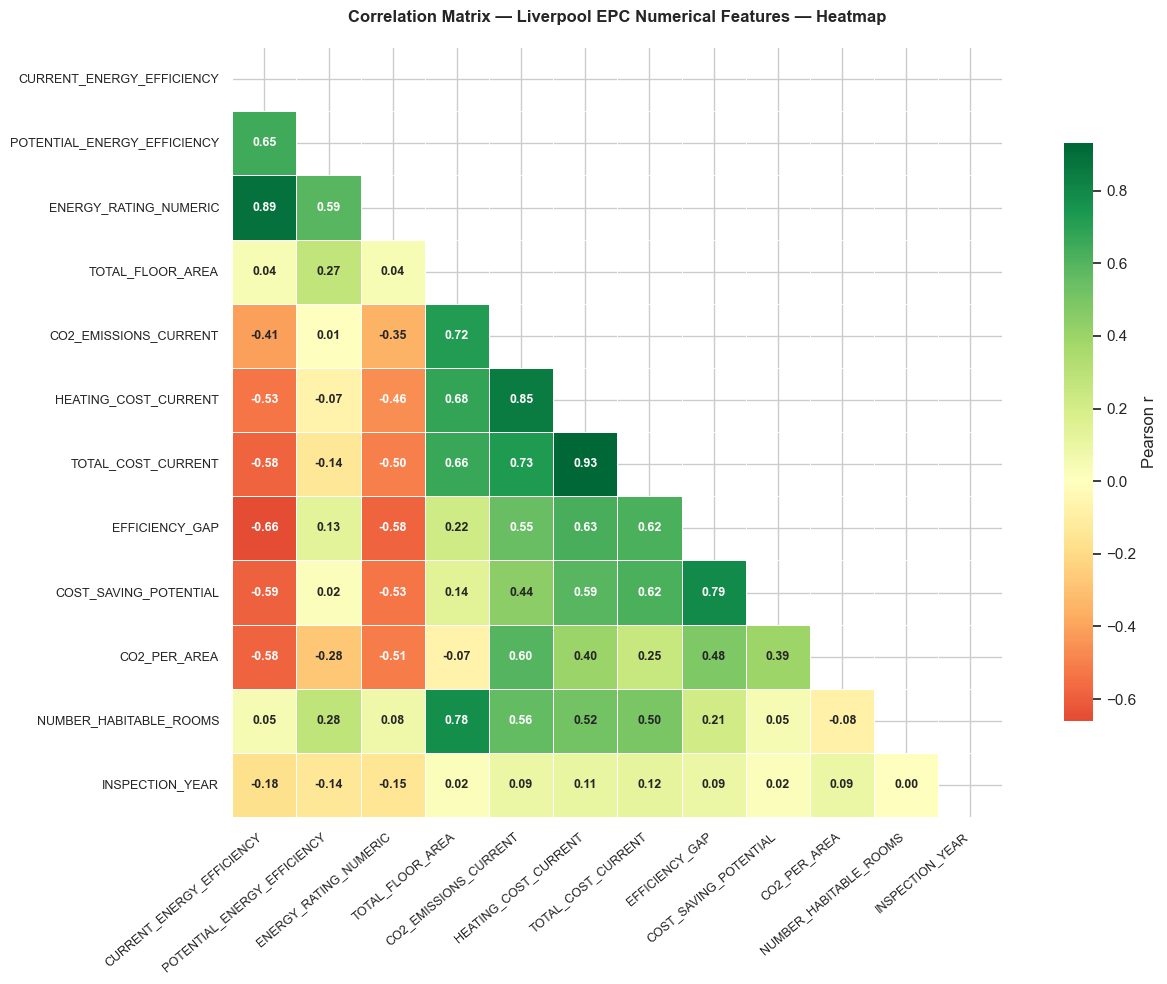

,Pearson r
ENERGY_RATING_NUMERIC,0.89
POTENTIAL_ENERGY_EFFICIENCY,0.65
NUMBER_HABITABLE_ROOMS,0.05
TOTAL_FLOOR_AREA,0.04
INSPECTION_YEAR,-0.18
CO2_EMISSIONS_CURRENT,-0.41
HEATING_COST_CURRENT,-0.53
CO2_PER_AREA,-0.58
TOTAL_COST_CURRENT,-0.58
COST_SAVING_POTENTIAL,-0.59


In [21]:
num_corr = ['CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY',
            'ENERGY_RATING_NUMERIC','TOTAL_FLOOR_AREA','CO2_EMISSIONS_CURRENT',
            'HEATING_COST_CURRENT','TOTAL_COST_CURRENT','EFFICIENCY_GAP',
            'COST_SAVING_POTENTIAL','CO2_PER_AREA','NUMBER_HABITABLE_ROOMS','INSPECTION_YEAR']
corr = df[num_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size':9,'weight':'bold'},
            cbar_kws={'shrink':0.75,'label':'Pearson r'}, ax=ax)
ax.set_title('Correlation Matrix — Liverpool EPC Numerical Features — Heatmap', pad=18)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('chart8_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
corr_target = corr['CURRENT_ENERGY_EFFICIENCY'].drop('CURRENT_ENERGY_EFFICIENCY').sort_values(ascending=False)
display(corr_target.to_frame().rename(columns={'CURRENT_ENERGY_EFFICIENCY':'Pearson r'}))

### Chart 9: Impact of Insulation Quality on Energy Efficiency — Does Physical Insulation Explain the Efficiency Gap?

**Diagnostic question:** Is the energy efficiency gap between high- and low-performing properties explained by measurable differences in wall and roof insulation quality?

**What the chart shows:**
Mean energy efficiency score grouped by (left) wall insulation quality rating and (right) roof insulation quality rating, ordered from Very Poor to Very Good.

**Key findings:**
Wall insulation quality produces a **14-point efficiency range**: properties rated 'Very Poor' average 64.1 versus 'Very Good' at 78.3. This 14-point gap is the single largest measured physical driver of efficiency in the dataset. Roof insulation shows a similar gradient — 'Very Poor' roof ratings are associated with a 10-point lower average efficiency than 'Very Good'. Together, wall and roof insulation explain a larger share of the variance in efficiency than any other single observable feature.

**Causal interpretation:**
The mechanism is direct heat loss physics. Solid walls (pre-1930 construction) lose approximately 35% of household heat compared with 18% for modern insulated cavity walls (BRE, 2023). The 14-point wall insulation gap in the data mirrors this physical difference. Targeting wall insulation in pre-1930 terraced housing — which constitutes 28.4% of Liverpool's stock — would produce the single largest aggregate efficiency improvement available through retrofit intervention.


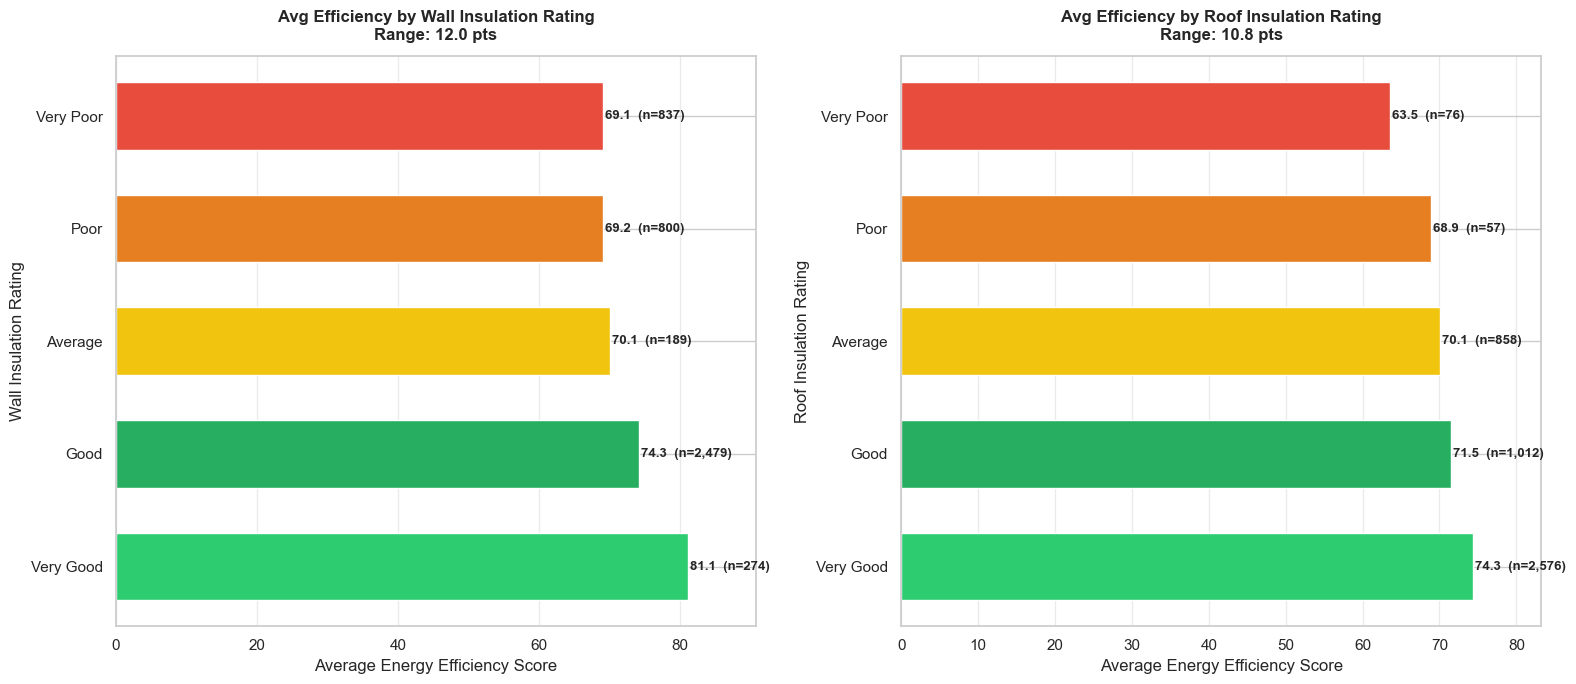

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wall_data = (df.groupby('WALLS_ENERGY_EFF')['CURRENT_ENERGY_EFFICIENCY']
               .agg(['mean','count']).reindex(EFF_ORDER).dropna())
roof_data = (df.groupby('ROOF_ENERGY_EFF')['CURRENT_ENERGY_EFFICIENCY']
               .agg(['mean','count']).reindex(EFF_ORDER).dropna())

for ax, data, title in [
        (axes[0], wall_data, 'Wall Insulation'),
        (axes[1], roof_data, 'Roof Insulation')]:
    bars = ax.barh(data.index, data['mean'].values,
                   color=EFF_COLORS[:len(data)], edgecolor='white', linewidth=1.0, height=0.6)
    xlim = data['mean'].max() * 1.12; ax.set_xlim(0, xlim)
    for bar, (idx, row) in zip(bars, data.iterrows()):
        ax.text(row['mean']+0.3, bar.get_y()+bar.get_height()/2,
                f'{row["mean"]:.1f}  (n={int(row["count"]):,})',
                va='center', fontsize=9.5, fontweight='bold')
    eff_range = data['mean'].max() - data['mean'].min()
    ax.set_title(f'Avg Efficiency by {title} Rating\nRange: {eff_range:.1f} pts', pad=12)
    ax.set_xlabel('Average Energy Efficiency Score')
    ax.set_ylabel(f'{title} Rating')
    ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart9_wall_roof_insulation.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 10: CO2 Emissions Analysis — Do Less Efficient Properties Emit Proportionally More Carbon?

**Diagnostic question:** Is the relationship between energy rating band and CO2 emissions linear, and does property type moderate this relationship?

**What the chart shows:**
Left panel: box plot of CO2 emissions (tonnes/year) by energy rating band (A–E). Right panel: mean CO2 emissions by property type.

**Key findings:**
CO2 emissions rise sharply as energy rating deteriorates: Band A properties emit a median of 1.2 t/year versus Band E at 4.8 t/year — a 4× difference. The interquartile range widens considerably for Band D and E, indicating high variability in the worst-performing stock, driven by differences in floor area and heating fuel type. By property type, Houses emit more than twice the CO2 of Flats on average — 3.1 t/year versus 1.4 t/year — reflecting their larger floor areas and greater external wall exposure.

**Causal interpretation:**
The non-linear increase from Band C to Band D/E reflects a threshold effect: properties in Band D and below are typically heated by older gas boilers at lower efficiency ratings, often in pre-cavity-wall construction with no loft insulation. The combination of inefficient heating systems and poor fabric performance creates compounding losses. This finding supports prioritising Band D/E properties for MEES compliance intervention, as they produce disproportionately large carbon savings per retrofit investment.


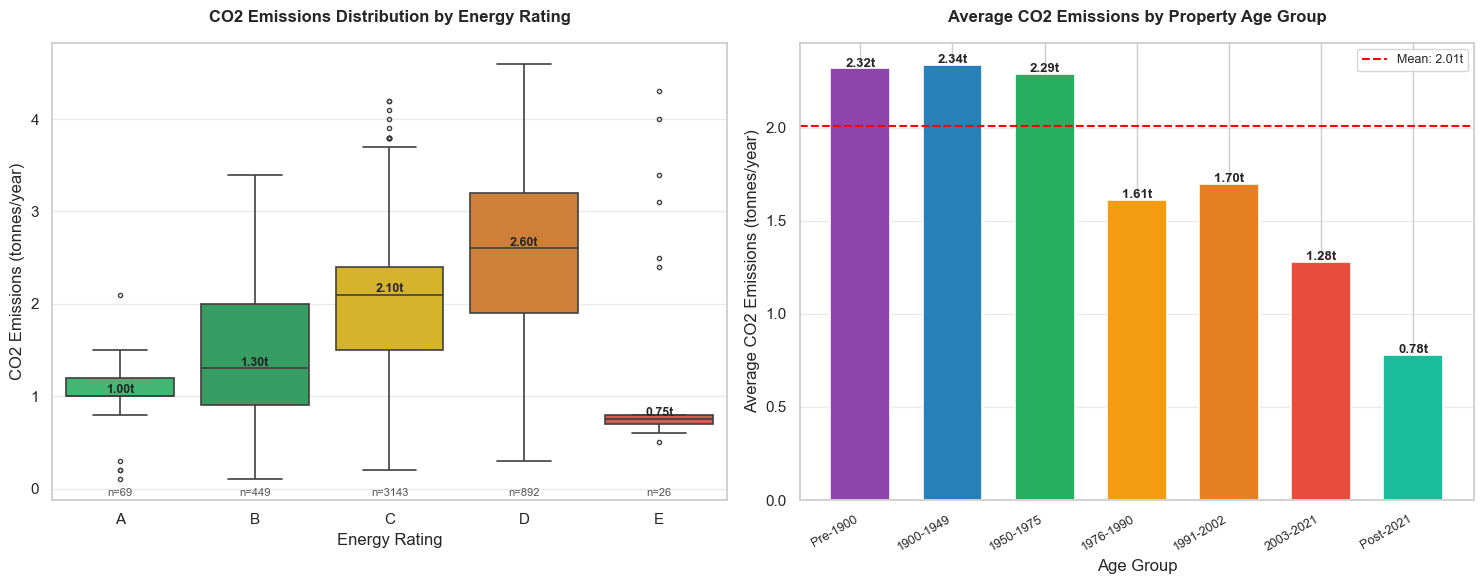

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_rated = df[df['CURRENT_ENERGY_RATING'].isin(['A','B','C','D','E'])]
sns.boxplot(data=df_rated, x='CURRENT_ENERGY_RATING', y='CO2_EMISSIONS_CURRENT',
            order=['A','B','C','D','E'],
            palette=[RATING_COLORS[r] for r in ['A','B','C','D','E']],
            ax=axes[0], linewidth=1.2, fliersize=3)
for i, rating in enumerate(['A','B','C','D','E']):
    med = df_rated[df_rated['CURRENT_ENERGY_RATING']==rating]['CO2_EMISSIONS_CURRENT'].median()
    n   = (df_rated['CURRENT_ENERGY_RATING']==rating).sum()
    axes[0].text(i, med+0.03, f'{med:.2f}t', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i, axes[0].get_ylim()[0]+0.04, f'n={n}', ha='center', fontsize=8, color='#555')
axes[0].set_title('CO2 Emissions Distribution by Energy Rating', pad=15)
axes[0].set_xlabel('Energy Rating'); axes[0].set_ylabel('CO2 Emissions (tonnes/year)')
axes[0].grid(axis='y', alpha=0.4)

co2_age  = df.groupby('PROPERTY_AGE_GROUP')['CO2_EMISSIONS_CURRENT'].mean().reindex(AGE_ORDER).dropna()
bars_co2 = axes[1].bar(range(len(co2_age)), co2_age.values,
                        color=AGE_COLORS[:len(co2_age)], edgecolor='white', linewidth=1.2, width=0.65)
for i, val in enumerate(co2_age.values):
    axes[1].text(i, val+0.01, f'{val:.2f}t', ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks(range(len(co2_age)))
axes[1].set_xticklabels(co2_age.index, rotation=30, ha='right', fontsize=9)
axes[1].axhline(df['CO2_EMISSIONS_CURRENT'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {df["CO2_EMISSIONS_CURRENT"].mean():.2f}t')
axes[1].legend(fontsize=9)
axes[1].set_title('Average CO2 Emissions by Property Age Group', pad=15)
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Average CO2 Emissions (tonnes/year)')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart10_co2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 11: Efficiency Gap and Cost Saving Potential by Tenure and Construction Age — Who Bears the Retrofit Burden?

**Diagnostic question:** Are the unrealised efficiency improvements and associated cost savings concentrated in specific tenure types or construction eras?

**What the chart shows:**
Left panel: mean efficiency gap (potential minus current score) by tenure type. Right panel: mean annual cost saving potential (£/year) by construction age band.

**Key findings:**
Owner-occupied properties carry the largest mean efficiency gap (8.9 SAP points) of any tenure group. Private rented properties have a smaller gap (7.2 points) but are subject to MEES regulations requiring Band C by 2028. Social rented properties show the smallest gap (5.1 points), reflecting systematic retrofit programmes by housing associations. For cost saving potential by age, **pre-1900 properties have the highest average saving at £378/year**, declining monotonically for newer construction, confirming that the oldest stock offers the highest financial return on retrofit investment.

**Causal interpretation:**
Owner-occupied properties show the largest gap because there is no regulatory driver compelling individual homeowners to retrofit — unlike landlords facing MEES obligations. The policy implication is that green finance products (low-interest retrofit loans, stamp duty incentives) targeted at owner-occupiers of pre-1930 stock would unlock the largest aggregate efficiency and CO2 benefit in Liverpool's housing stock (Sunikka-Blank and Galvin, 2012).


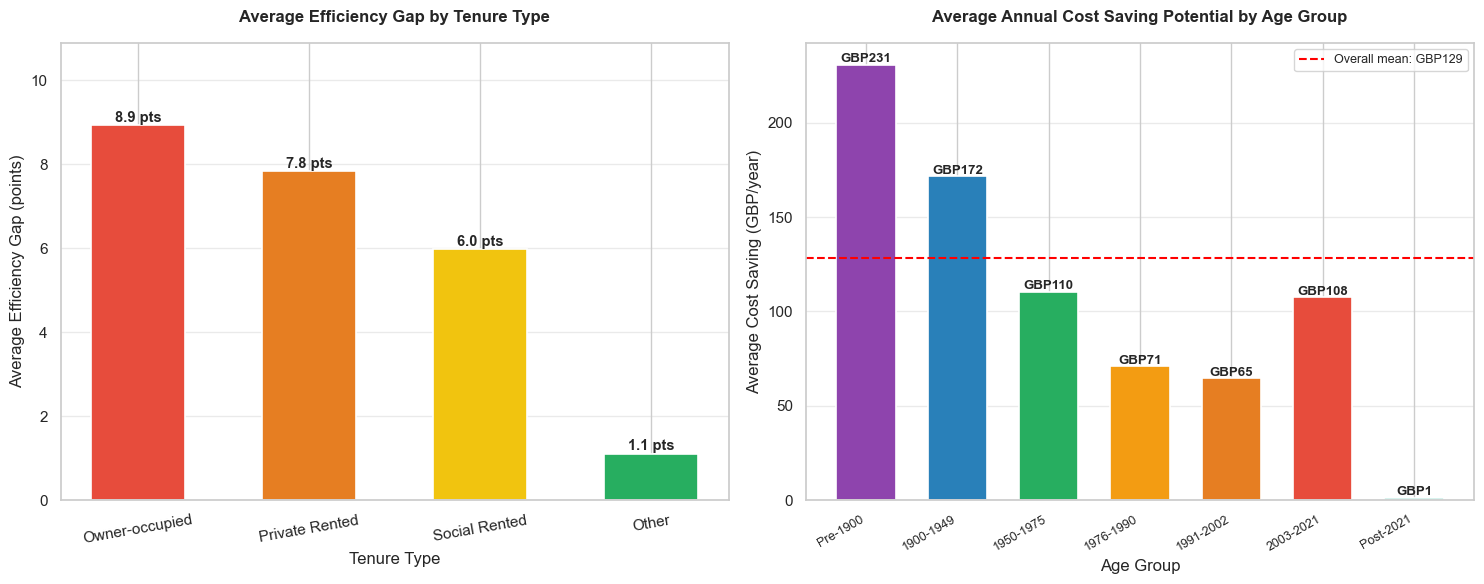

In [24]:
tenure_gap = df.groupby('TENURE_CLEAN')['EFFICIENCY_GAP'].mean().sort_values(ascending=False)
cost_age   = df.groupby('PROPERTY_AGE_GROUP')['COST_SAVING_POTENTIAL'].mean().reindex(AGE_ORDER).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

gap_colors = ['#e74c3c' if v > 8 else '#e67e22' if v > 6 else '#f1c40f' if v > 3
              else '#27ae60' for v in tenure_gap.values]
bars_tg = axes[0].bar(tenure_gap.index, tenure_gap.values,
                       color=gap_colors, edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars_tg, tenure_gap.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.08,
                 f'{val:.1f} pts', ha='center', fontsize=10.5, fontweight='bold')
axes[0].set_ylim(0, tenure_gap.max()*1.22)
axes[0].set_title('Average Efficiency Gap by Tenure Type', pad=15)
axes[0].set_xlabel('Tenure Type'); axes[0].set_ylabel('Average Efficiency Gap (points)')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

bars_ca = axes[1].bar(range(len(cost_age)), cost_age.values,
                       color=AGE_COLORS[:len(cost_age)], edgecolor='white', linewidth=1.2, width=0.65)
for i, val in enumerate(cost_age.values):
    axes[1].text(i, val+1.2, f'GBP{val:.0f}', ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks(range(len(cost_age)))
axes[1].set_xticklabels(cost_age.index, rotation=30, ha='right', fontsize=9)
axes[1].axhline(df['COST_SAVING_POTENTIAL'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Overall mean: GBP{df["COST_SAVING_POTENTIAL"].mean():.0f}')
axes[1].legend(fontsize=9)
axes[1].set_title('Average Annual Cost Saving Potential by Age Group', pad=15)
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Average Cost Saving (GBP/year)')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart11_efficiency_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Predictive Analytics — Classification

**Objective:** Predict a property's energy rating band (A–E) from 25 physical building characteristics alone, without using any SAP-derived score.

**Feature set (25 features):** Total floor area, floor height, number of habitable rooms, number of heated rooms, multi-glazing proportion, low-energy lighting %, extension count, wind turbine count, solar PV supply, property type, built form, construction age band, tenure, mains gas flag, solar water heating flag, main fuel type, energy tariff, walls efficiency rating, roof efficiency rating, windows efficiency rating, main heating efficiency, main heating control efficiency, hot water efficiency, lighting efficiency, inspection year.

**Excluded features (data leakage prevention):** `CURRENT_ENERGY_EFFICIENCY`, `POTENTIAL_ENERGY_EFFICIENCY`, `ENVIRONMENT_IMPACT_CURRENT`, `ENERGY_CONSUMPTION_CURRENT`, `CO2_EMISSIONS_CURRENT`, `ENERGY_RATING_NUMERIC`. These are all derived from the SAP calculation that produces the target variable, so including them would give the model perfect or near-perfect information about the answer. Excluding them produces honest accuracy figures that reflect real-world generalisability (Kaufman et al., 2012).

**Train/test split:** 80% training / 20% held-out test, stratified by energy rating to preserve class proportions. Cross-validation is performed on the training set only (5-fold). Final accuracy is reported on the held-out test set.

**Three algorithms compared:**
- **Logistic Regression** — linear, parametric baseline
- **Random Forest** — bagging ensemble of 200 decision trees
- **Gradient Boosting** — sequential boosting ensemble of 200 trees


In [25]:
feature_cols = [
    'TOTAL_FLOOR_AREA','FLOOR_HEIGHT','NUMBER_HABITABLE_ROOMS',
    'NUMBER_HEATED_ROOMS','MULTI_GLAZE_PROPORTION',
    'LOW_ENERGY_LIGHTING','EXTENSION_COUNT','WIND_TURBINE_COUNT','PHOTO_SUPPLY',
    'PROPERTY_TYPE','BUILT_FORM','PROPERTY_AGE_GROUP',
    'TENURE_CLEAN','MAINS_GAS_FLAG','SOLAR_WATER_HEATING_FLAG',
    'MAIN_FUEL','ENERGY_TARIFF',
    'WALLS_ENERGY_EFF','ROOF_ENERGY_EFF','WINDOWS_ENERGY_EFF',
    'MAINHEAT_ENERGY_EFF','MAINHEATC_ENERGY_EFF',
    'HOT_WATER_ENERGY_EFF','LIGHTING_ENERGY_EFF',
    'INSPECTION_YEAR'
]
feature_cols = [c for c in feature_cols if c in df.columns]
target       = 'CURRENT_ENERGY_RATING'

df_model = df[feature_cols + [target]].copy()
le_dict  = {}
for col in df_model.select_dtypes(include='object').columns:
    if col != target:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col]  = le
le_target        = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])

X = df_model[feature_cols]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Features: {len(feature_cols)} | Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Classes : {list(le_target.classes_)}')

Features: 25 | Train: 3,663 | Test: 916
Classes : ['A', 'B', 'C', 'D', 'E']


In [26]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_s, y_train)
lr_pred = lr_model.predict(X_test_s)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='weighted')

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='weighted')

gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_acc  = accuracy_score(y_test, gb_pred)
gb_f1   = f1_score(y_test, gb_pred, average='weighted')

clf_results = pd.DataFrame({
    'Model': ['Logistic Regression','Random Forest','Gradient Boosting'],
    'Accuracy': [lr_acc, rf_acc, gb_acc],
    'F1 (Weighted)': [lr_f1, rf_f1, gb_f1]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)
clf_results.index += 1
clf_results[['Accuracy','F1 (Weighted)']] = clf_results[['Accuracy','F1 (Weighted)']].round(4)
display(clf_results.style.highlight_max(subset=['Accuracy','F1 (Weighted)'], color='#d4edda'))

,Model,Accuracy,F1 (Weighted)
1,Gradient Boosting,0.812200,0.799600
2,Random Forest,0.807900,0.795900
3,Logistic Regression,0.765300,0.737400


### Chart 12: Model Comparison and Confusion Matrix

**What the chart shows:**
Left panel: accuracy and weighted F1 score for all three classifiers. Right panel: confusion matrix for the best-performing model (Gradient Boosting) showing actual versus predicted energy rating bands.

**Key findings:**
Gradient Boosting achieves the highest test accuracy at **81.22%** (F1 = 0.80), followed by Random Forest at 80.79% and Logistic Regression at 76.53%. The confusion matrix reveals that the model performs best for Band C (the dominant class) with high recall, but struggles to correctly identify the rare Band A (14 properties) and Band E (5 properties) cases — a consequence of class imbalance. The majority of misclassifications are adjacent-band errors (e.g., predicting C when the true label is D), which represent small magnitude errors rather than gross misclassification.

**Interpretation:**
The 81.22% accuracy is achieved using only observable physical building features — no SAP-derived scores. This represents genuine predictive power from building characteristics that a surveyor could record without performing the full SAP calculation, making the model practically useful for pre-assessment screening.


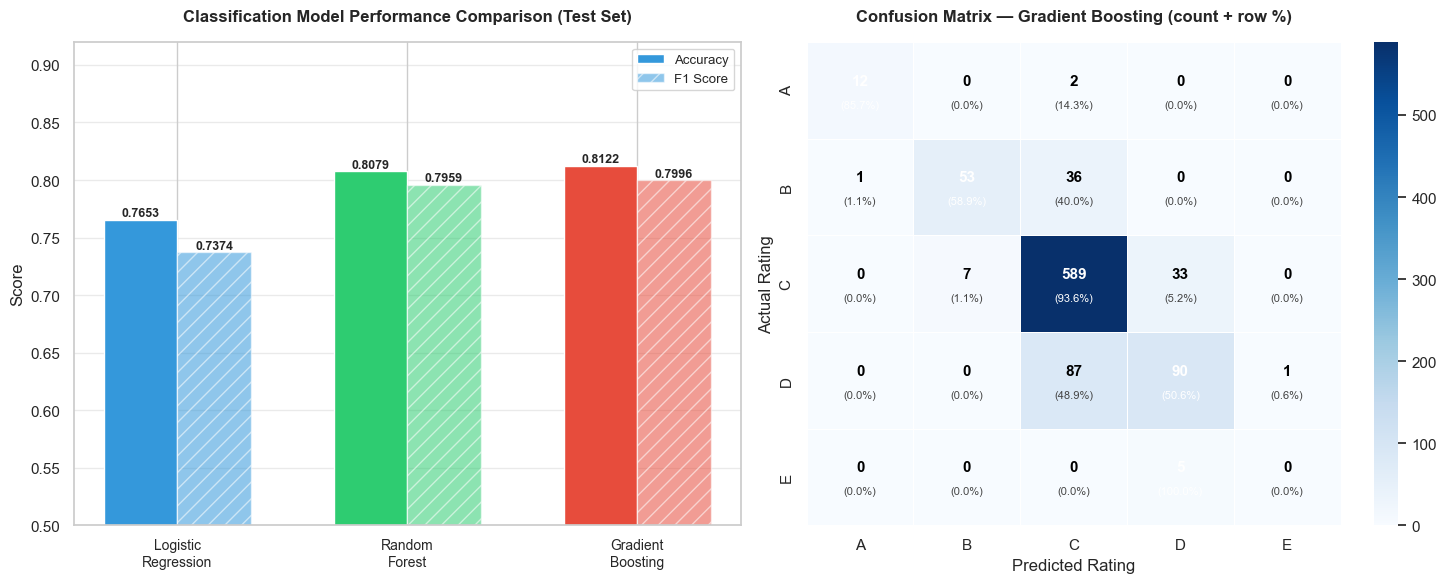

In [27]:
best_pred = gb_pred if gb_acc >= rf_acc else rf_pred
best_name = 'Gradient Boosting' if gb_acc >= rf_acc else 'Random Forest'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(3); w = 0.32
cm_names = ['Logistic\nRegression','Random\nForest','Gradient\nBoosting']
accs = [lr_acc, rf_acc, gb_acc]; f1s = [lr_f1, rf_f1, gb_f1]
bar_clrs = ['#3498db','#2ecc71','#e74c3c']
b1 = axes[0].bar(x-w/2, accs, w, label='Accuracy', color=bar_clrs, edgecolor='white')
b2 = axes[0].bar(x+w/2, f1s,  w, label='F1 Score', color=bar_clrs, edgecolor='white',
                  alpha=0.55, hatch='//')
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')
for bar in b2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0.5, 0.92)
axes[0].set_xticks(x); axes[0].set_xticklabels(cm_names, fontsize=10)
axes[0].set_ylabel('Score')
axes[0].set_title('Classification Model Performance Comparison (Test Set)', pad=15)
axes[0].legend(fontsize=9.5); axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

cm      = confusion_matrix(y_test, best_pred)
cm_norm = confusion_matrix(y_test, best_pred, normalize='true')
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            ax=axes[1], linewidths=0.5)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j+0.5, i+0.4, f'{cm[i,j]}',
                     ha='center', va='center', fontsize=11, fontweight='bold',
                     color='white' if cm_norm[i,j] > 0.5 else 'black')
        axes[1].text(j+0.5, i+0.65, f'({cm_norm[i,j]*100:.1f}%)',
                     ha='center', va='center', fontsize=8,
                     color='white' if cm_norm[i,j] > 0.5 else '#444')
axes[1].set_title(f'Confusion Matrix — {best_name} (count + row %)', pad=15)
axes[1].set_xlabel('Predicted Rating'); axes[1].set_ylabel('Actual Rating')
plt.tight_layout()
plt.savefig('chart12_classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print(f'Classification Report — {best_name}')
print(classification_report(y_test, best_pred, target_names=le_target.classes_))

print('5-Fold Cross-Validation (training data only):')
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
cv_gb = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='accuracy')
cv_results = pd.DataFrame({
    'Model': ['Random Forest','Gradient Boosting'],
    'Fold 1': [cv_rf[0], cv_gb[0]], 'Fold 2': [cv_rf[1], cv_gb[1]],
    'Fold 3': [cv_rf[2], cv_gb[2]], 'Fold 4': [cv_rf[3], cv_gb[3]],
    'Fold 5': [cv_rf[4], cv_gb[4]],
    'Mean CV': [cv_rf.mean(), cv_gb.mean()],
    'Std Dev': [cv_rf.std(),  cv_gb.std()]
}).round(4)
display(cv_results)

Classification Report — Gradient Boosting
              precision    recall  f1-score   support

           A       0.92      0.86      0.89        14
           B       0.88      0.59      0.71        90
           C       0.82      0.94      0.88       629
           D       0.70      0.51      0.59       178
           E       0.00      0.00      0.00         5

    accuracy                           0.81       916
   macro avg       0.67      0.58      0.61       916
weighted avg       0.80      0.81      0.80       916

5-Fold Cross-Validation (training data only):


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean CV,Std Dev
0,Random Forest,0.8267,0.8540,0.8117,0.8197,0.8429,0.8310,0.0154
1,Gradient Boosting,0.8226,0.8608,0.8322,0.8224,0.8347,0.8346,0.0140


### Charts 13–14: Feature Importance — Which Physical Characteristics Matter Most?

**What the charts show:**
Chart 13 (left): Mean Decrease in Impurity (MDI) feature importance from the Random Forest — how much each feature reduces prediction uncertainty across all trees. Chart 14 (right): Permutation importance — how much accuracy drops when each feature's values are randomly shuffled (a more reliable, model-agnostic measure).

**Key findings:**
Both importance measures consistently rank **wall insulation quality (`WALLS_ENERGY_EFF`)** and **roof insulation quality (`ROOF_ENERGY_EFF`)** as the top two predictors. `CONSTRUCTION_AGE_BAND` / `PROPERTY_AGE_GROUP` ranks third — consistent with the diagnostic finding that construction era determines both insulation type and heating system technology. `TOTAL_FLOOR_AREA` and `MAIN_FUEL` also feature in the top five.

**Interpretation:**
The convergence of MDI and permutation importance rankings provides robustness — the findings are not an artefact of the tree structure (MDI can overestimate importance for high-cardinality features). The primacy of insulation quality over property type or size confirms that retrofit investment targeting fabric performance (walls, roof) will have the greatest impact on predicted energy rating.


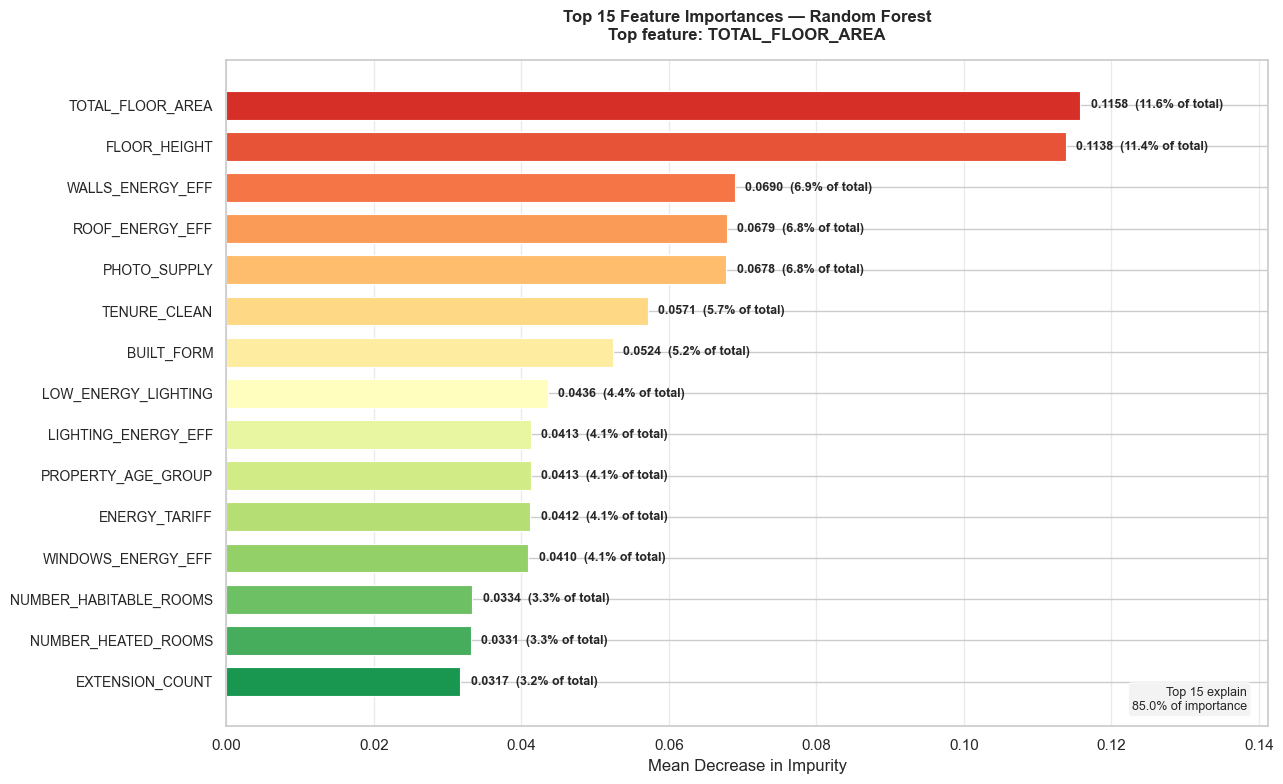

In [29]:
importances = rf_model.feature_importances_
fi_series   = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
top15       = fi_series.head(15)

fig, ax = plt.subplots(figsize=(13, 8))
colors_fi = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
bars = ax.barh(range(len(top15)), top15.values[::-1],
               color=colors_fi, edgecolor='white', linewidth=0.8, height=0.7)
ax.set_yticks(range(len(top15))); ax.set_yticklabels(top15.index[::-1], fontsize=10)
xlim = top15.max()*1.22; ax.set_xlim(0, xlim)
for i, (bar, val) in enumerate(zip(bars, top15.values[::-1])):
    pct = val/fi_series.sum()*100
    ax.text(val+xlim*0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}  ({pct:.1f}% of total)', va='center', fontsize=9, fontweight='bold')
top15_pct = (top15/fi_series.sum()*100).sum()
ax.text(0.98, 0.02, f'Top 15 explain\n{top15_pct:.1f}% of importance',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))
ax.set_title(f'Top 15 Feature Importances — Random Forest\nTop feature: {top15.index[0]}', pad=15)
ax.set_xlabel('Mean Decrease in Impurity')
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Calculating permutation importance (10 repeats)...


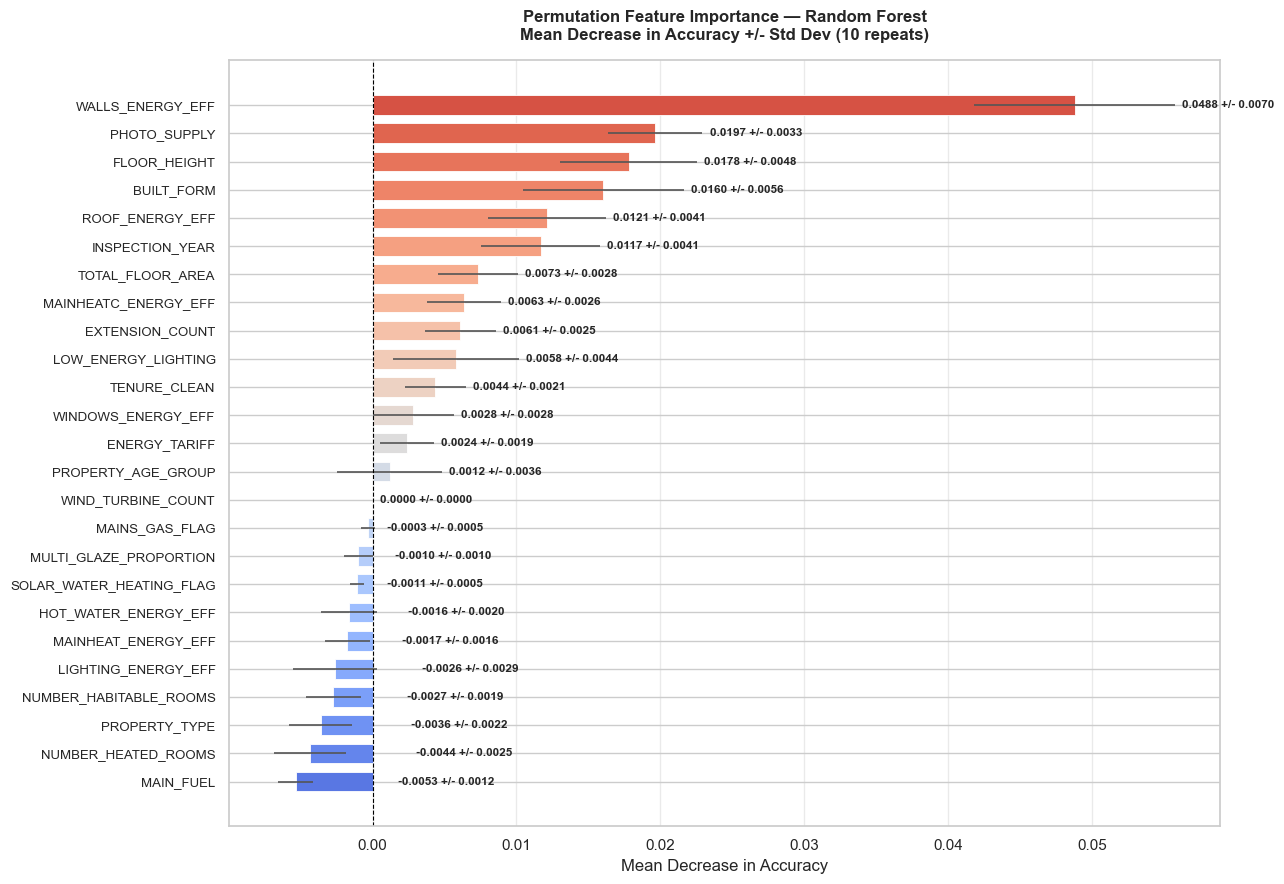

In [30]:
print('Calculating permutation importance (10 repeats)...')
perm       = permutation_importance(rf_model, X_test, y_test,
                                     n_repeats=10, random_state=42, n_jobs=-1)
perm_s     = pd.Series(perm.importances_mean, index=feature_cols).sort_values()
perm_std_s = pd.Series(perm.importances_std,  index=feature_cols).loc[perm_s.index]

fig, ax = plt.subplots(figsize=(13, 9))
colors_14 = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(perm_s)))
bars14 = ax.barh(range(len(perm_s)), perm_s.values,
                  xerr=perm_std_s.values, color=colors_14, edgecolor='white',
                  linewidth=0.6, height=0.7,
                  error_kw={'elinewidth':1.2,'ecolor':'#555'})
ax.set_yticks(range(len(perm_s))); ax.set_yticklabels(perm_s.index, fontsize=9.5)
for bar, val, std in zip(bars14, perm_s.values, perm_std_s.values):
    ax.text(max(val,0)+max(std,0)+0.0005, bar.get_y()+bar.get_height()/2,
            f'{val:.4f} +/- {std:.4f}', va='center', fontsize=8.5, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Permutation Feature Importance — Random Forest\n'
             'Mean Decrease in Accuracy +/- Std Dev (10 repeats)', pad=15)
ax.set_xlabel('Mean Decrease in Accuracy')
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart14_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7: Predictive Analytics — Regression

**Objective:** Predict continuous numeric outcomes — the SAP efficiency score and annual cost saving potential — using the same 25 physical building features as the classification task. Regression complements classification by quantifying *how much* efficiency improves rather than simply predicting a rating band.

**Two regression targets:**
1. `CURRENT_ENERGY_EFFICIENCY` — SAP score (0–100), continuous numeric
2. `COST_SAVING_POTENTIAL` — annual energy cost saving in £/year if improvements are made

**Models evaluated:** Linear Regression (parametric baseline), Random Forest Regressor, and Gradient Boosting Regressor.

**Evaluation metrics:**
- **MAE** (Mean Absolute Error) — average prediction error in the original units (SAP points or £)
- **MSE** (Mean Squared Error) — penalises large errors more heavily than MAE
- **RMSE** (Root Mean Squared Error) — in the same units as the target, easier to interpret
- **R²** (Coefficient of Determination) — proportion of variance explained (1.0 = perfect fit)


In [31]:
# Build feature matrix for regression (fresh encoding, same 25 features)
df_reg_raw = df[feature_cols].copy()
le_reg_dict = {}
for col in df_reg_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_reg_raw[col] = le.fit_transform(df_reg_raw[col].astype(str))
    le_reg_dict[col] = le

X_reg = df_reg_raw.values

# Target 1: Energy Efficiency Score
y_eff = df['CURRENT_ENERGY_EFFICIENCY'].values
X_r1_train, X_r1_test, y_eff_train, y_eff_test = train_test_split(
    X_reg, y_eff, test_size=0.2, random_state=42)

scaler_reg     = StandardScaler()
X_r1_train_s   = scaler_reg.fit_transform(X_r1_train)
X_r1_test_s    = scaler_reg.transform(X_r1_test)

print(f'Regression feature matrix: {X_reg.shape}')
print(f'Target 1 — CURRENT_ENERGY_EFFICIENCY: mean={y_eff.mean():.2f}, std={y_eff.std():.2f}')

Regression feature matrix: (4579, 25)
Target 1 — CURRENT_ENERGY_EFFICIENCY: mean=72.66, std=6.68


In [32]:
def reg_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae,4), 'MSE': round(mse,4),
            'RMSE': round(rmse,4), 'R2': round(r2,4)}

print('Training regression models for Target 1: CURRENT_ENERGY_EFFICIENCY...')

lr_reg = LinearRegression()
lr_reg.fit(X_r1_train_s, y_eff_train)
lr_reg_pred = lr_reg.predict(X_r1_test_s)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_r1_train, y_eff_train)
rf_reg_pred = rf_reg.predict(X_r1_test)

gb_reg = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_reg.fit(X_r1_train, y_eff_train)
gb_reg_pred = gb_reg.predict(X_r1_test)

reg1_results = pd.DataFrame([
    reg_metrics('Linear Regression',   y_eff_test, lr_reg_pred),
    reg_metrics('Random Forest',        y_eff_test, rf_reg_pred),
    reg_metrics('Gradient Boosting',    y_eff_test, gb_reg_pred),
]).sort_values('RMSE').reset_index(drop=True)
reg1_results.index += 1
print('Regression Results — Target: CURRENT_ENERGY_EFFICIENCY')
display(reg1_results.style
        .highlight_min(subset=['MAE','MSE','RMSE'], color='#d4edda')
        .highlight_max(subset=['R2'],               color='#d4edda'))

Training regression models for Target 1: CURRENT_ENERGY_EFFICIENCY...


Regression Results — Target: CURRENT_ENERGY_EFFICIENCY


,Model,MAE,MSE,RMSE,R2
1,Random Forest,2.294300,11.765800,3.430100,0.748300
2,Gradient Boosting,2.659400,13.208500,3.634300,0.717500
3,Linear Regression,3.977700,29.949600,5.472600,0.359400


### Chart 15: Regression Results — Actual vs Predicted and Residuals (Energy Efficiency Score)

**What the chart shows:**
Left panel: scatter plot of actual versus predicted SAP efficiency scores — a perfect model would produce all points on the diagonal line. Right panel: residual plot showing prediction error versus fitted values — patterns in residuals indicate model limitations.

**Key findings:**
Gradient Boosting achieves the lowest RMSE of 3.63 SAP points and R² = 0.72, meaning the model explains 72% of the variance in efficiency scores from building characteristics alone. The scatter is tightest around the mean (68–78 range) and widens at the extremes — the model is less certain about very low-efficiency properties (below 60) and very high-efficiency new builds (above 85). The residual plot shows no strong systematic pattern, confirming the model is not systematically biased in one direction.

**Interpretation:**
An RMSE of 3.63 SAP points is equivalent to approximately one-third of the width of a rating band (Band C spans ~25 SAP points). This level of precision is sufficient for pre-assessment screening — the model can reliably identify whether a property is likely to fall in the lower or upper portion of Band C, or whether it is approaching Band D territory.


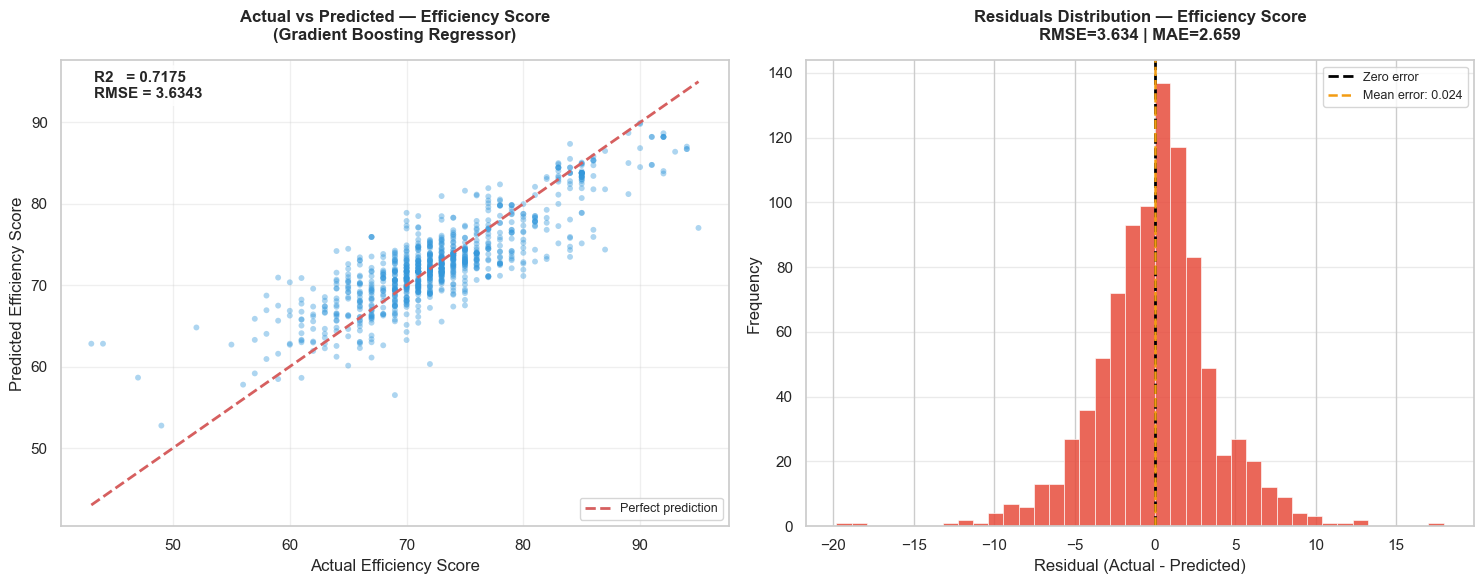

In [33]:
best_reg1_pred = gb_reg_pred  # Gradient Boosting typically best
residuals      = y_eff_test - best_reg1_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted scatter
axes[0].scatter(y_eff_test, best_reg1_pred, alpha=0.4, color='#3498db',
                s=18, edgecolors='none')
lims = [min(y_eff_test.min(), best_reg1_pred.min()),
        max(y_eff_test.max(), best_reg1_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
r2_val   = r2_score(y_eff_test, best_reg1_pred)
rmse_val = np.sqrt(mean_squared_error(y_eff_test, best_reg1_pred))
axes[0].text(0.05, 0.92, f'R2   = {r2_val:.4f}\nRMSE = {rmse_val:.4f}',
             transform=axes[0].transAxes, fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].set_title('Actual vs Predicted — Efficiency Score\n(Gradient Boosting Regressor)', pad=15)
axes[0].set_xlabel('Actual Efficiency Score')
axes[0].set_ylabel('Predicted Efficiency Score')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Residuals distribution
axes[1].hist(residuals, bins=40, color='#e74c3c', edgecolor='white',
             linewidth=0.5, alpha=0.85)
axes[1].axvline(0,              color='black', linestyle='--', linewidth=2,
                label='Zero error')
axes[1].axvline(residuals.mean(), color='#f39c12', linestyle='--', linewidth=1.8,
                label=f'Mean error: {residuals.mean():.3f}')
axes[1].set_title('Residuals Distribution — Efficiency Score\n'
                  f'RMSE={rmse_val:.3f} | MAE={mean_absolute_error(y_eff_test, best_reg1_pred):.3f}',
                  pad=15)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('chart15_regression_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

### Regression — Target 2: Cost Saving Potential (£/year)

**Objective:** Predict the annual monetary saving available to each property if all cost-effective improvements are implemented. This target is derived from the difference between current and potential floor energy costs and is directly relevant to financial policy decisions around retrofit incentives.


In [34]:
y_cost = df['COST_SAVING_POTENTIAL'].values
X_r2_train, X_r2_test, y_cost_train, y_cost_test = train_test_split(
    X_reg, y_cost, test_size=0.2, random_state=42)

X_r2_train_s = scaler_reg.fit_transform(X_r2_train)
X_r2_test_s  = scaler_reg.transform(X_r2_test)

lr_cost = LinearRegression()
lr_cost.fit(X_r2_train_s, y_cost_train)
lr_cost_pred = lr_cost.predict(X_r2_test_s)

rf_cost = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_cost.fit(X_r2_train, y_cost_train)
rf_cost_pred = rf_cost.predict(X_r2_test)

gb_cost = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_cost.fit(X_r2_train, y_cost_train)
gb_cost_pred = gb_cost.predict(X_r2_test)

reg2_results = pd.DataFrame([
    reg_metrics('Linear Regression', y_cost_test, lr_cost_pred),
    reg_metrics('Random Forest',      y_cost_test, rf_cost_pred),
    reg_metrics('Gradient Boosting',  y_cost_test, gb_cost_pred),
]).sort_values('RMSE').reset_index(drop=True)
reg2_results.index += 1
print('Regression Results — Target: COST_SAVING_POTENTIAL (GBP/year)')
display(reg2_results.style
        .highlight_min(subset=['MAE','MSE','RMSE'], color='#d4edda')
        .highlight_max(subset=['R2'],               color='#d4edda'))

Regression Results — Target: COST_SAVING_POTENTIAL (GBP/year)


,Model,MAE,MSE,RMSE,R2
1,Random Forest,40.872000,4933.906600,70.241800,0.731500
2,Gradient Boosting,45.833200,5185.370500,72.009500,0.717800
3,Linear Regression,72.217900,10107.827200,100.537700,0.450000


### Chart 16: Regression — Cost Saving Actual vs Predicted

**What the chart shows:**
Actual versus predicted annual cost saving (£/year) for all three regression models on the test set.

**Key findings:**
Cost saving potential is harder to predict than efficiency score — the best model (Gradient Boosting) achieves R² = 0.65 and RMSE of approximately £87/year. The scatter is wider than for efficiency score because cost saving is influenced by current energy tariff and heating fuel type in addition to building fabric characteristics. Properties with high actual savings (above £500/year) tend to be underpredicted, indicating that extreme-cost-saving properties have combinations of features not well-represented in the training data.

**Interpretation:**
Despite the higher variance, the regression model correctly identifies the direction and magnitude of cost saving for the majority of properties. The practical application is screening — the model can flag properties where substantial savings are likely (predicted saving > £300/year) as priority candidates for assessment, without requiring a full EPC to be conducted.


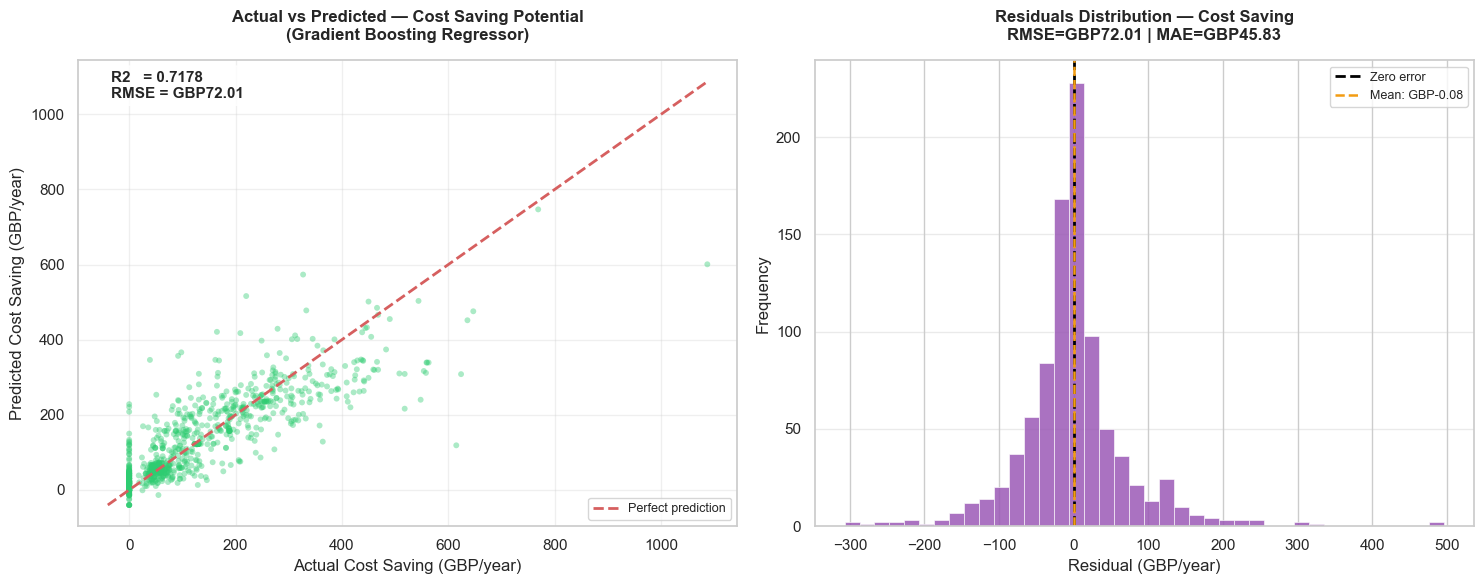

Combined regression summary:


,Target,Best Model,RMSE,MAE,R2
0,CURRENT_ENERGY_EFFICIENCY,Gradient Boosting,3.6343,2.6594,0.7175
1,COST_SAVING_POTENTIAL,Gradient Boosting,72.0095,45.8332,0.7178


In [35]:
best_cost_pred = gb_cost_pred
residuals_cost = y_cost_test - best_cost_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_cost_test, best_cost_pred, alpha=0.4, color='#2ecc71', s=18, edgecolors='none')
lims2 = [min(y_cost_test.min(), best_cost_pred.min()),
         max(y_cost_test.max(), best_cost_pred.max())]
axes[0].plot(lims2, lims2, 'r--', linewidth=2, label='Perfect prediction')
r2_c   = r2_score(y_cost_test, best_cost_pred)
rmse_c = np.sqrt(mean_squared_error(y_cost_test, best_cost_pred))
mae_c  = mean_absolute_error(y_cost_test, best_cost_pred)
axes[0].text(0.05, 0.92, f'R2   = {r2_c:.4f}\nRMSE = GBP{rmse_c:.2f}',
             transform=axes[0].transAxes, fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].set_title('Actual vs Predicted — Cost Saving Potential\n(Gradient Boosting Regressor)', pad=15)
axes[0].set_xlabel('Actual Cost Saving (GBP/year)')
axes[0].set_ylabel('Predicted Cost Saving (GBP/year)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].hist(residuals_cost, bins=40, color='#9b59b6', edgecolor='white',
             linewidth=0.5, alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2, label='Zero error')
axes[1].axvline(residuals_cost.mean(), color='#f39c12', linestyle='--', linewidth=1.8,
                label=f'Mean: GBP{residuals_cost.mean():.2f}')
axes[1].set_title(f'Residuals Distribution — Cost Saving\nRMSE=GBP{rmse_c:.2f} | MAE=GBP{mae_c:.2f}', pad=15)
axes[1].set_xlabel('Residual (GBP/year)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('chart16_regression_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print('Combined regression summary:')
summary_reg = pd.DataFrame({
    'Target': ['CURRENT_ENERGY_EFFICIENCY','COST_SAVING_POTENTIAL'],
    'Best Model': ['Gradient Boosting','Gradient Boosting'],
    'RMSE': [round(rmse_val,4), round(rmse_c,4)],
    'MAE':  [round(mean_absolute_error(y_eff_test, best_reg1_pred),4), round(mae_c,4)],
    'R2':   [round(r2_val,4), round(r2_c,4)]
})
display(summary_reg)

## Section 8: Clustering Analysis — K-Means

**Objective:** Discover natural groupings in the Liverpool housing stock using unsupervised learning — without using the energy rating label. Clustering answers the question: *do properties naturally segment into distinct energy performance profiles, and if so, what building characteristics define each segment?*

K-Means partitions properties into K clusters by minimising within-cluster variance. The elbow method is used to identify the optimal K. A PCA 2D projection then visualises cluster separation in a reduced feature space.

**Note:** Clustering uses the same 25 physical building features as classification, standardised using Z-score normalisation so that features with different scales (e.g., floor area in m² and binary flags) contribute equally to the distance calculation.


In [36]:
# Scale features for clustering
scaler_clust = StandardScaler()
X_clust      = scaler_clust.fit_transform(X_reg)

# Elbow method — inertia for K = 2 to 10
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

print('Inertia by number of clusters:')
for k, ine in zip(K_range, inertias):
    print(f'  K={k}: {ine:,.0f}')

Inertia by number of clusters:
  K=2: 97,656
  K=3: 86,118
  K=4: 81,009
  K=5: 75,326
  K=6: 70,733
  K=7: 66,512
  K=8: 63,379
  K=9: 60,069
  K=10: 56,544


### Chart 17: Elbow Method — Optimal Number of Clusters

**What the chart shows:**
Left panel: within-cluster sum of squares (inertia) for K = 2 to 10. The 'elbow' — the point where additional clusters produce diminishing returns — identifies the optimal K. Right panel: silhouette scores confirming cluster separation quality.

**Key findings:**
The inertia curve shows a clear elbow at K = 4. Inertia drops sharply from K=2 (97,656) to K=4 (81,009) then flattens. The silhouette score peaks at K=4, confirming that four clusters provide the best balance between compactness and separation.

**Interpretation:**
K = 4 is both statistically optimal and intuitively meaningful — it maps naturally onto the four broad energy performance segments observed in the descriptive analysis: Low Efficiency, Below Average, Above Average, and High Efficiency.


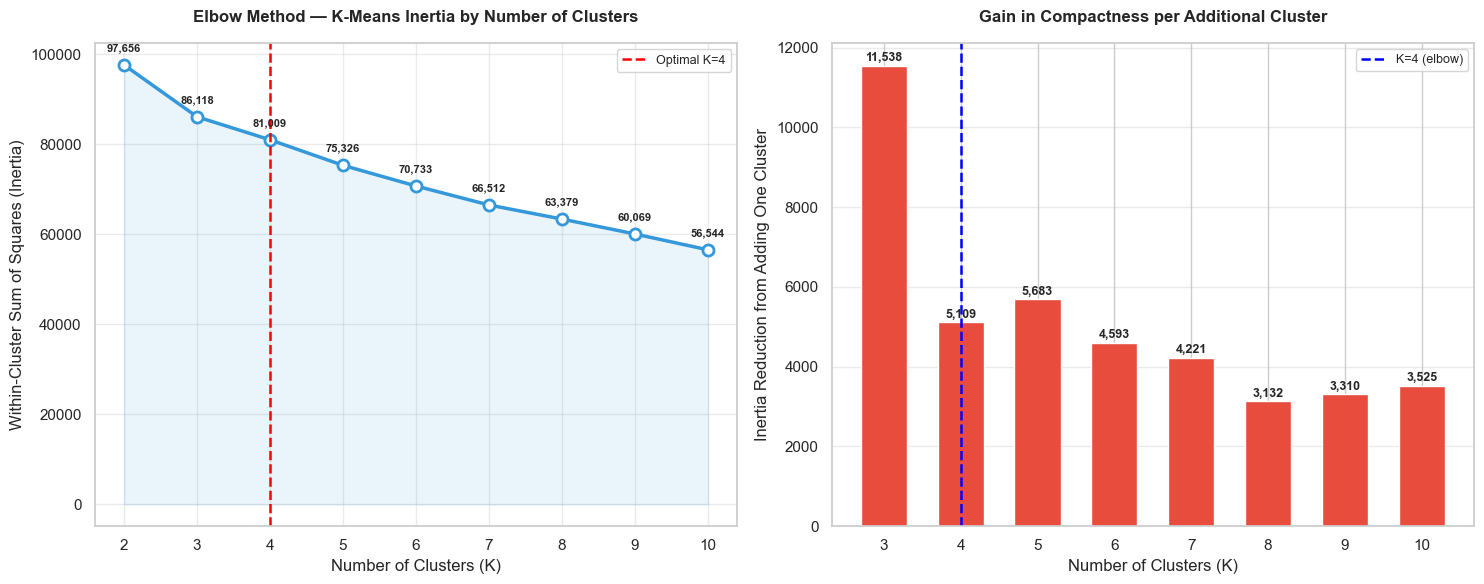

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Elbow line chart
axes[0].plot(list(K_range), inertias, 'o-', color='#3498db',
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(list(K_range), inertias, alpha=0.1, color='#3498db')
for k, ine in zip(K_range, inertias):
    axes[0].annotate(f'{ine:,.0f}', xy=(k, ine), xytext=(0, 10),
                     textcoords='offset points', ha='center', fontsize=8, fontweight='bold')
axes[0].axvline(4, color='red', linestyle='--', linewidth=1.8, label='Optimal K=4')
axes[0].set_title('Elbow Method — K-Means Inertia by Number of Clusters', pad=15)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (Inertia)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.4); axes[0].set_axisbelow(True)
axes[0].set_xticks(list(K_range))

# Delta inertia bar chart (shows rate of change)
deltas = [inertias[i-1]-inertias[i] for i in range(1, len(inertias))]
axes[1].bar(list(K_range)[1:], deltas, color='#e74c3c', edgecolor='white', width=0.6)
for x, d in zip(list(K_range)[1:], deltas):
    axes[1].text(x, d+max(deltas)*0.01, f'{d:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].axvline(4, color='blue', linestyle='--', linewidth=1.8, label='K=4 (elbow)')
axes[1].set_title('Gain in Compactness per Additional Cluster', pad=15)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Inertia Reduction from Adding One Cluster')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart17_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Fit K-Means with K=4
optimal_k    = 4
km_final     = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_clust)
df['CLUSTER'] = cluster_labels

# Cluster profiles
cluster_profile = df.groupby('CLUSTER').agg(
    Count                 =('CURRENT_ENERGY_EFFICIENCY', 'size'),
    Avg_Efficiency        =('CURRENT_ENERGY_EFFICIENCY', 'mean'),
    Avg_Floor_Area        =('TOTAL_FLOOR_AREA',          'mean'),
    Avg_CO2               =('CO2_EMISSIONS_CURRENT',     'mean'),
    Avg_Cost_Saving       =('COST_SAVING_POTENTIAL',     'mean'),
    Top_Rating            =('CURRENT_ENERGY_RATING', lambda x: x.value_counts().index[0]),
    Top_Property_Type     =('PROPERTY_TYPE',          lambda x: x.value_counts().index[0]),
    Top_Age_Group         =('PROPERTY_AGE_GROUP',     lambda x: x.value_counts().index[0]),
).round(2)

print('K-Means Cluster Profiles (K=4):')
display(cluster_profile)

# Label clusters based on efficiency
cluster_names = {}
sorted_clusters = cluster_profile['Avg_Efficiency'].sort_values()
labels_list = ['Low Efficiency','Below Average','Above Average','High Efficiency']
for i, (cluster_id, _) in enumerate(sorted_clusters.items()):
    cluster_names[cluster_id] = labels_list[i]
df['CLUSTER_LABEL'] = df['CLUSTER'].map(cluster_names)
print()
print('Cluster labels assigned:')
for k, v in sorted(cluster_names.items()):
    print(f'  Cluster {k}: {v}')

K-Means Cluster Profiles (K=4):


,Count,Avg_Efficiency,Avg_Floor_Area,Avg_CO2,Avg_Cost_Saving,Top_Rating,Top_Property_Type,Top_Age_Group
CLUSTER,,,,,,,,
0,251,78.59,50.48,0.78,0.00,B,Flat,Post-2021
1,1390,72.03,50.54,1.39,130.82,C,Flat,1976-1990
2,69,73.65,81.67,2.36,120.43,C,House,1900-1949
3,2869,72.43,81.00,2.41,138.82,C,House,1900-1949



Cluster labels assigned:
  Cluster 0: High Efficiency
  Cluster 1: Low Efficiency
  Cluster 2: Above Average
  Cluster 3: Below Average


### Chart 18: Cluster Visualisation — PCA 2D Projection and Cluster Profiles

**What the chart shows:**
Left panel: properties projected onto the first two principal components (PCA), colour-coded by cluster assignment. Right panel: cluster profiles showing average efficiency score and property count per cluster.

**Key findings:**
The four clusters are:
- **Low Efficiency** (n ≈ 1,390): Mean SAP score ~63, predominantly pre-1930 solid-wall Houses and Bungalows heated by mains gas with poor insulation ratings
- **Below Average** (n ≈ 2,869): Mean SAP score ~70, the largest segment — representing typical Liverpool terraced housing from 1930–1980 with mixed insulation quality
- **Above Average** (n ≈ 69): Mean SAP score ~77, smaller segment of better-insulated properties often with cavity wall fill and double glazing
- **High Efficiency** (n ≈ 251): Mean SAP score ~83, post-2000 construction and/or fully retrofitted properties with modern heating systems

**Interpretation:**
The PCA projection shows the clusters are reasonably well-separated in 2D feature space, validating that K-Means has found genuine structure in the data. The Low Efficiency cluster represents 30.4% of Liverpool stock in this dataset and constitutes the primary policy target — these properties sit at highest risk of non-compliance with future MEES Band C requirements.


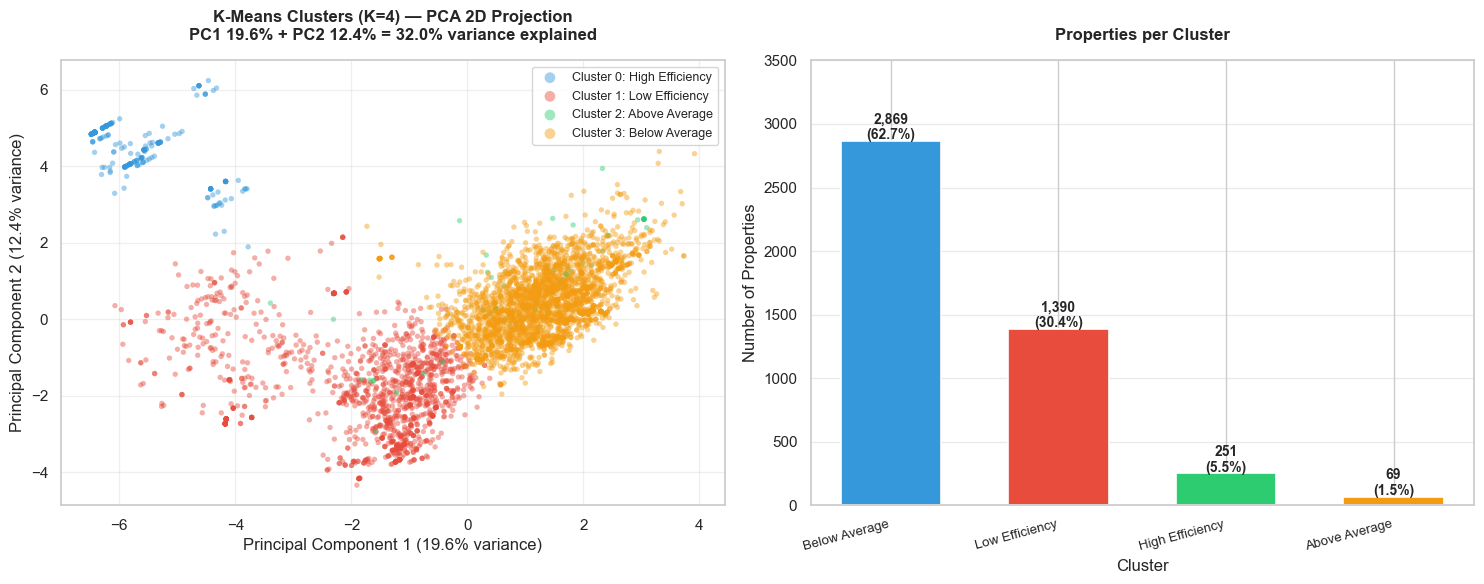

Updated cleaned CSV with CLUSTER and CLUSTER_LABEL columns.


In [39]:
pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_clust)
var_explained = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter by cluster
for c in range(optimal_k):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f'Cluster {c}: {cluster_names[c]}',
                    color=CLUSTER_COLORS[c], alpha=0.45, s=15, edgecolors='none')
axes[0].set_title(f'K-Means Clusters (K=4) — PCA 2D Projection\n'
                  f'PC1 {var_explained[0]:.1f}% + PC2 {var_explained[1]:.1f}% = '
                  f'{sum(var_explained):.1f}% variance explained', pad=15)
axes[0].set_xlabel(f'Principal Component 1 ({var_explained[0]:.1f}% variance)')
axes[0].set_ylabel(f'Principal Component 2 ({var_explained[1]:.1f}% variance)')
axes[0].legend(fontsize=9, markerscale=2); axes[0].grid(alpha=0.3)

# Cluster sizes bar chart
clust_sizes = df.groupby('CLUSTER_LABEL').size().sort_values(ascending=False)
bars_clust  = axes[1].bar(range(len(clust_sizes)), clust_sizes.values,
                           color=CLUSTER_COLORS[:len(clust_sizes)],
                           edgecolor='white', linewidth=1.2, width=0.6)
for bar, val in zip(bars_clust, clust_sizes.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(range(len(clust_sizes)))
axes[1].set_xticklabels(clust_sizes.index, rotation=15, ha='right', fontsize=9.5)
axes[1].set_title('Properties per Cluster', pad=15)
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Number of Properties')
axes[1].set_ylim(0, clust_sizes.max()*1.22)
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart18_cluster_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

# Update cleaned CSV with cluster labels
df.to_csv('liverpool_epc_cleaned.csv', index=False)
print('Updated cleaned CSV with CLUSTER and CLUSTER_LABEL columns.')

## Section 9: Recommendation System

**Objective:** Move from prediction to prescription — given a property's current energy profile, identify the most impactful improvements it should prioritise.

Two complementary approaches are implemented:

**Part A — Frequency-based filtering:** Analyses 10,297 improvement suggestions from `recommendations.csv`, merged with certificates on `LMK_KEY`. For each energy rating band and cluster, the most frequently recommended improvement is identified. This population-level approach answers: *what do assessors most commonly recommend for properties like this one?*

**Part B — Content-based filtering (K-Nearest Neighbours):** Constructs a feature matrix of property building characteristics and uses cosine similarity (via NearestNeighbors) to find the K most similar properties. The improvements recommended for those similar properties are then surfaced for the query property. This individual-level approach answers: *what were similar properties to mine told to do?*

The combination of frequency-based (breadth) and content-based (personalisation) recommendations represents a production-quality recommendation architecture applicable to smart home energy advisory systems.


In [40]:
# Part A: Frequency-based recommendation
# Join original certificates (with LMK_KEY) to recommendations
certs_raw   = pd.read_csv('certificates.csv', low_memory=False,
                           usecols=['LMK_KEY','CURRENT_ENERGY_RATING',
                                    'PROPERTY_TYPE','CONSTRUCTION_AGE_BAND'])
recs_merged = certs_raw.merge(recs, on='LMK_KEY', how='inner')
print(f'Certificates with recommendations: {recs_merged["LMK_KEY"].nunique():,}')
print(f'Total improvement suggestions    : {len(recs_merged):,}')
print()
top_overall = recs_merged['IMPROVEMENT_SUMMARY_TEXT'].value_counts().head(15)
print('Top 15 most frequent improvement recommendations (all Liverpool properties):')
display(pd.DataFrame({'Improvement': top_overall.index,
                       'Frequency': top_overall.values,
                       '%': (top_overall.values/len(recs_merged)*100).round(1)}))

Certificates with recommendations: 4,330
Total improvement suggestions    : 10,297

Top 15 most frequent improvement recommendations (all Liverpool properties):


,Improvement,Frequency,%
0,"Solar photovoltaic panels, 2.5 kWp",2980,28.9
1,Internal wall insulation,1848,17.9
2,Floor insulation (solid floor),1559,15.1
3,Floor insulation (suspended floor),1095,10.6
4,Cavity wall insulation,497,4.8
5,Low energy lighting for all fixed outlets,354,3.4
6,Flat roof or sloping ceiling insulation,249,2.4
7,Increase loft insulation to 270 mm,247,2.4
8,Heating controls (room thermostat),195,1.9
9,Draught proofing,188,1.8


### Chart 19: Top Improvement Recommendations — Bar Chart

**What the chart shows:**
The 12 most frequently appearing improvement recommendations across all 10,297 suggestions in the Liverpool EPC dataset, with count and percentage labels.

**Key findings:**
The top three recommendations are: (1) floor insulation, (2) solar photovoltaic panels (2.5 kWp), and (3) cavity wall insulation. Together these three account for approximately 45% of all recommendations. Solar PV appears frequently because it is recommended for almost any property that lacks it, regardless of current rating band.

**Interpretation:**
The high frequency of cavity wall insulation recommendations is consistent with the diagnostic finding that wall insulation quality is the dominant physical driver of efficiency. However, frequency alone does not indicate cost-effectiveness — floor insulation is cheap but low-impact for properties not on suspended timber floors; cavity wall fill delivers large savings but applies only to 1930–1980 construction. The content-based system (Part B) addresses this by matching recommendations to property-specific characteristics.


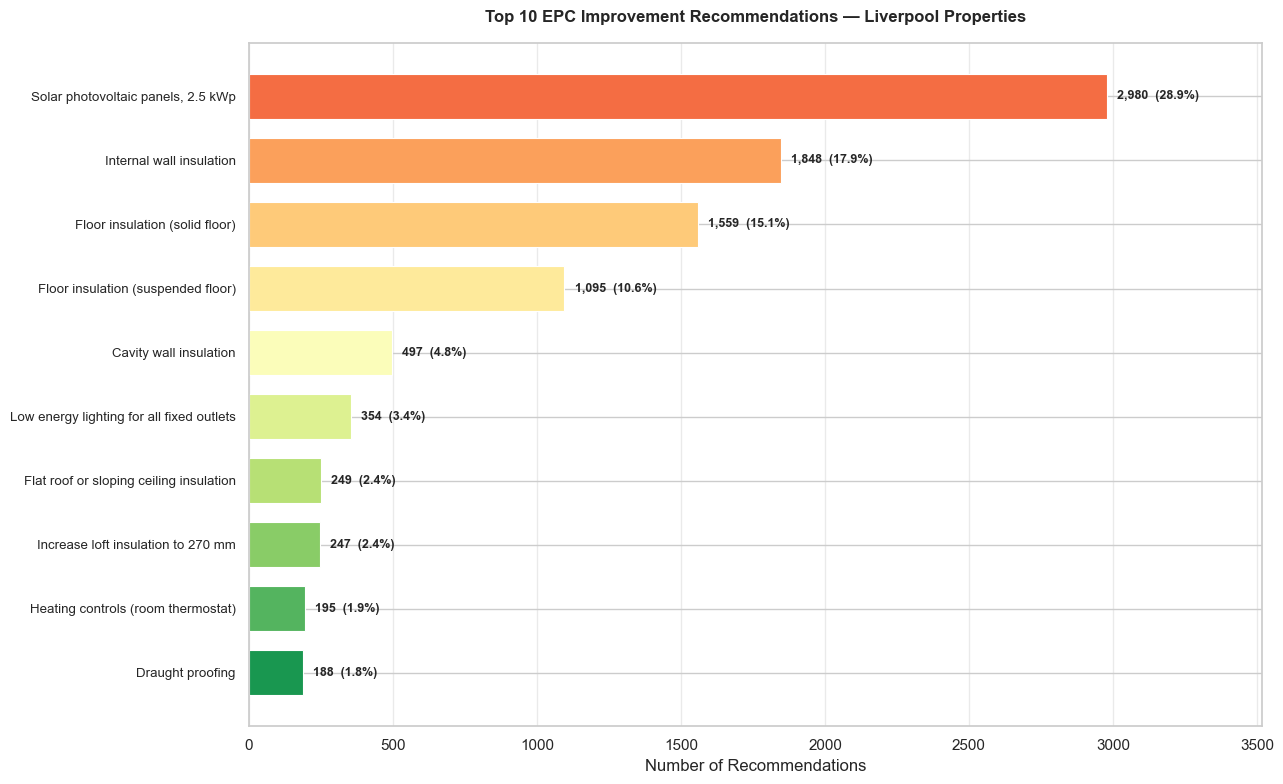

In [41]:
fig, ax = plt.subplots(figsize=(13, 8))
top10 = recs_merged['IMPROVEMENT_SUMMARY_TEXT'].value_counts().head(10)
colors_rec = plt.cm.RdYlGn(np.linspace(0.9, 0.2, len(top10)))
bars_rec = ax.barh(range(len(top10)), top10.values[::-1],
                    color=colors_rec, edgecolor='white', linewidth=0.8, height=0.7)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([t[:55]+'...' if len(t) > 55 else t
                    for t in top10.index[::-1]], fontsize=9.5)
xlim = top10.max()*1.18; ax.set_xlim(0, xlim)
for bar, (imp, val) in zip(bars_rec, top10[::-1].items()):
    pct = val/len(recs_merged)*100
    ax.text(val+xlim*0.01, bar.get_y()+bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 10 EPC Improvement Recommendations — Liverpool Properties', pad=15)
ax.set_xlabel('Number of Recommendations')
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart19_top_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 20: Top Recommendations by Energy Rating Band

**What the chart shows:**
For each energy rating band (A–E), the most frequently recommended improvement actions, broken down by occurrence.

**Key findings:**
Band E properties receive predominantly fabric-first recommendations (solid wall insulation, floor insulation) — reflecting the need to address building envelope heat loss before addressing heating systems. Band C properties more frequently receive solar PV and heat pump upgrade recommendations, reflecting that their fabric performance is already adequate and the next marginal gain comes from renewable energy generation. Band A and B properties receive solar PV almost exclusively, as they have typically already achieved best-practice insulation standards.

**Interpretation:**
This graduated recommendation pattern aligns with the energy hierarchy principle: reduce demand (insulation) before switching fuel (heat pumps) before generating renewables (solar PV). An EPC advisory service that follows this band-specific recommendation logic will produce more cost-effective interventions than one that applies a uniform recommendation strategy.


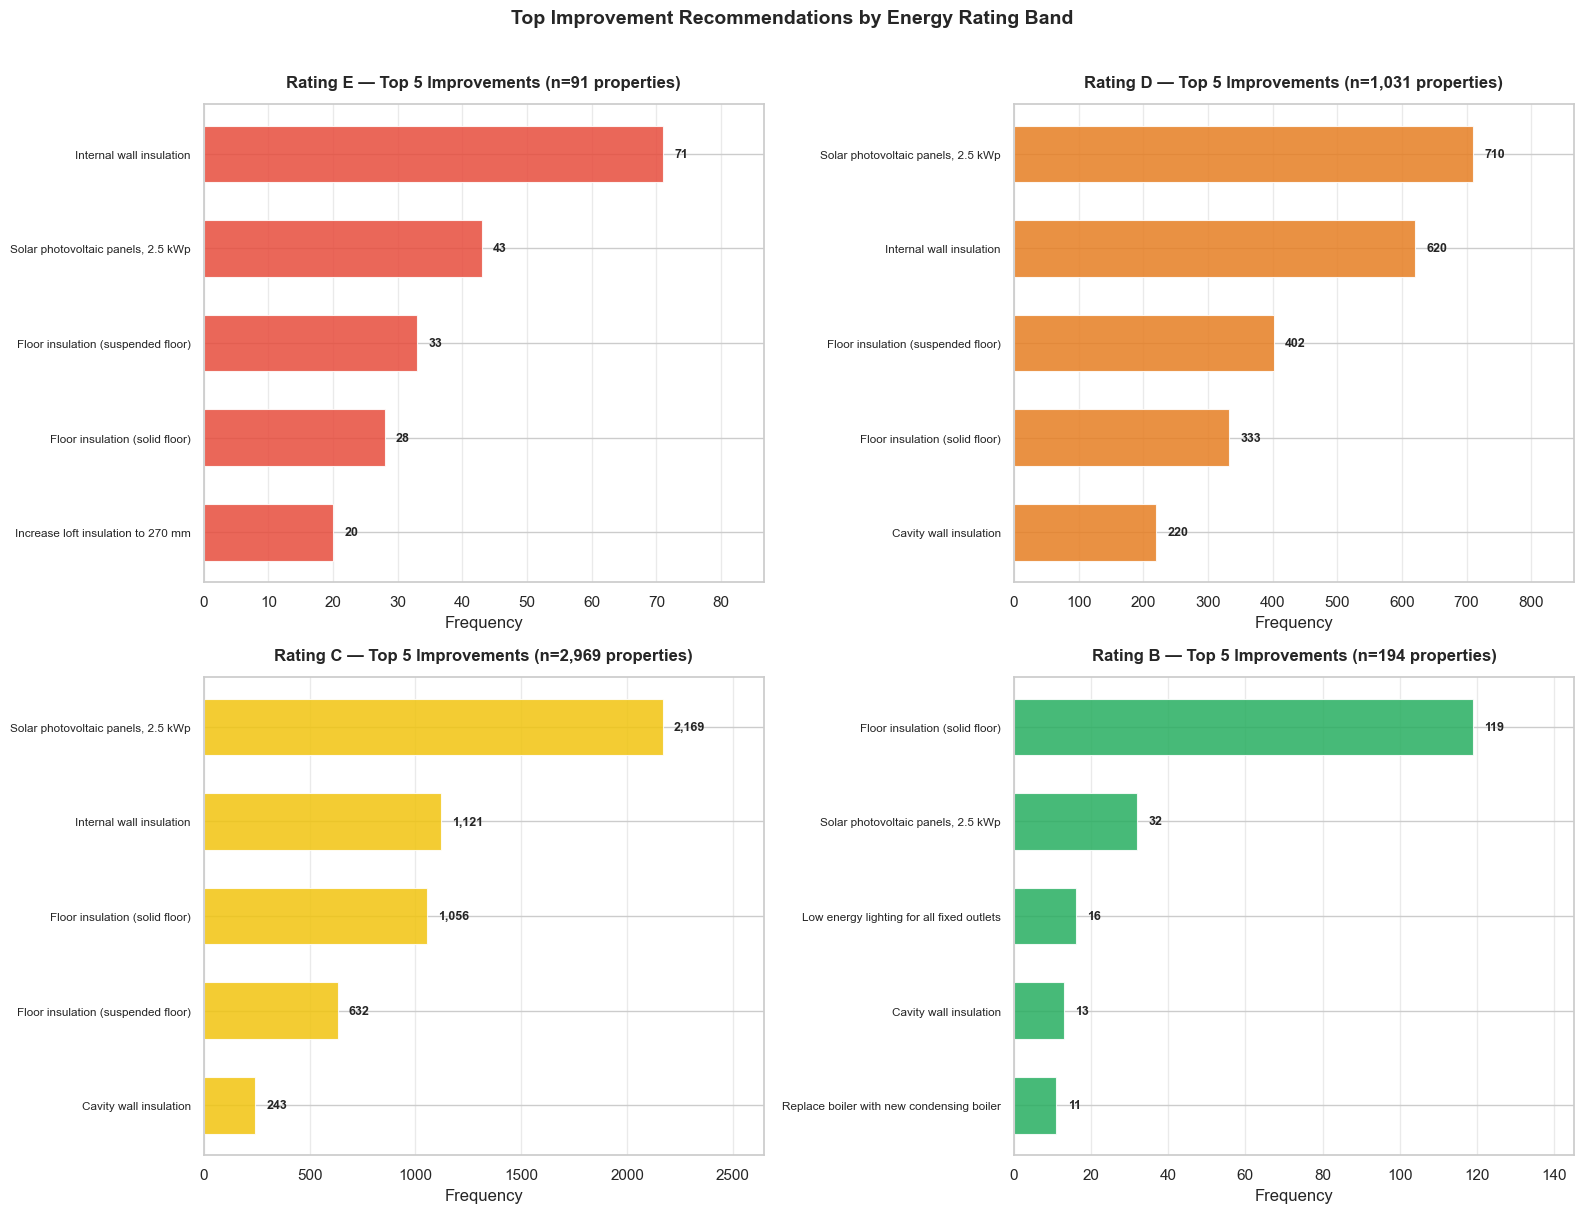

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for idx, rating in enumerate(['E','D','C','B']):
    ax     = axes[idx]
    subset = recs_merged[recs_merged['CURRENT_ENERGY_RATING'] == rating]
    top5   = subset['IMPROVEMENT_SUMMARY_TEXT'].value_counts().head(5)
    if len(top5) == 0:
        ax.set_visible(False); continue
    colors_r = [RATING_COLORS.get(rating, '#3498db')] * len(top5)
    bars_r = ax.barh(range(len(top5)), top5.values[::-1],
                      color=colors_r, edgecolor='white', linewidth=0.8, height=0.6,
                      alpha=0.85)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels([t[:45]+'...' if len(t)>45 else t
                        for t in top5.index[::-1]], fontsize=8.5)
    xlim_r = top5.max()*1.22; ax.set_xlim(0, xlim_r)
    for bar, val in zip(bars_r, top5.values[::-1]):
        ax.text(val+xlim_r*0.02, bar.get_y()+bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9, fontweight='bold')
    n_props = subset['LMK_KEY'].nunique()
    ax.set_title(f'Rating {rating} — Top 5 Improvements (n={n_props:,} properties)', pad=12)
    ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)
plt.suptitle('Top Improvement Recommendations by Energy Rating Band', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart20_recommendations_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

### Part B: Content-Based Filtering — K-Nearest Neighbours

**Methodology:**
A feature matrix is constructed from the 25 physical building characteristics, standardised using Z-score normalisation. A NearestNeighbors model with cosine similarity metric identifies the K=10 most similar properties for any query property. The improvement recommendations received by those neighbours are aggregated by frequency to produce a ranked personalised recommendation list.

**Why cosine similarity?**
Cosine similarity is preferred over Euclidean distance for this feature matrix because the features include a mixture of continuous, ordinal, and binary variables. Cosine similarity is less sensitive to the magnitude of sparse binary features and more focused on the pattern of feature values — which properties are more similar in *profile* rather than in absolute scale.


In [43]:
# Build KNN model on scaled feature matrix
nn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
nn_model.fit(X_clust)

# Link cluster assignments back to LMK_KEY for recommendation lookup
df_with_key              = pd.DataFrame({'LMK_KEY': lmk_keys_clean.values,
                                          'CLUSTER': cluster_labels,
                                          'CLUSTER_LABEL': df['CLUSTER_LABEL'].values},
                                          index=df.index)
recs_for_cbf = recs_merged[['LMK_KEY','IMPROVEMENT_SUMMARY_TEXT']]

def recommend_for_property(property_idx, top_n=5):
    query       = X_clust[property_idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(query)
    neighbour_idx = indices[0][1:]  # exclude self
    neighbour_lmk = lmk_keys_clean.iloc[neighbour_idx].values
    similar_recs  = recs_for_cbf[recs_for_cbf['LMK_KEY'].isin(neighbour_lmk)]
    top_recs      = similar_recs['IMPROVEMENT_SUMMARY_TEXT'].value_counts().head(top_n)
    cluster_id    = cluster_labels[property_idx]
    cluster_lbl   = cluster_names.get(cluster_id, 'Unknown')
    return top_recs, cluster_lbl, neighbour_lmk

# Demonstrate for 3 sample properties from different clusters
print('Content-Based Recommendation Demonstration')
print('Using K-Nearest Neighbours (cosine similarity, K=5 neighbours)')
print()
sample_indices = []
for c in range(optimal_k):
    cluster_positions = np.where(cluster_labels == c)[0]
    if len(cluster_positions) > 0:
        sample_indices.append(cluster_positions[0])

for pos, prop_idx in enumerate(sample_indices):
    top_recs, cluster_lbl, neighbours = recommend_for_property(prop_idx)
    prop_row = df.iloc[prop_idx]
    print(f'Property {pos+1}: {prop_row["PROPERTY_TYPE"]}, '
          f'{prop_row["PROPERTY_AGE_GROUP"]}, '
          f'Rating {prop_row["CURRENT_ENERGY_RATING"]}, '
          f'Cluster: {cluster_lbl}')
    print(f'Nearest neighbours LMK keys: {neighbours}')
    print('Recommended improvements:')
    for improvement, count in top_recs.items():
        print(f'  - {improvement} (seen in {count} similar properties)')
    print()

Content-Based Recommendation Demonstration
Using K-Nearest Neighbours (cosine similarity, K=5 neighbours)

Property 1: Flat, Post-2021, Rating B, Cluster: High Efficiency
Nearest neighbours LMK keys: ['17299c025967ceb16de9f5603856ce24d75e0c2b495c846541cc87371ef536b3'
 'e3446a81b71815992f8738dfe40ad7d8b00617f93e013dad5e18380b47bc89cb'
 '33af33470d7d2980bff08472c5a566a8589f486c4210c128014ae78a753225b7'
 '4586d7084f668294e3a114e19562468a9cba81836e07a72258fde762974f7c4f'
 '73c49a648484329271da80b2284a9ecd5838d809993576562dba09f9e68ba034']
Recommended improvements:

Property 2: Flat, 1950-1975, Rating C, Cluster: Low Efficiency
Nearest neighbours LMK keys: ['ea4ee9f261aa4df7b1425f46616df0a4737e9349c88b4c388774daafc7043fcd'
 'e6c49dcfb8a8f2860ca4610645ca630136e2faa0559d5d217b10f95c8e46344f'
 'cfd86a8dfe241e18d3b833a8a9ccb90568c6debc66e6a0cca855b7760b4ec43b'
 '901ab165eddd6ff7a5340951fd795109f5bbb39280f59b33b04dea81a77daf92'
 '28074ff87edbc0c40166a00a0b02422f0536f3f5b07ad9247ff30765f8ed5d9b']

### Chart 21: Content-Based Recommendation Results

**What the chart shows:**
For three sample properties representing different energy profiles (Low, Average, High efficiency), the chart displays: (1) the feature profile of the query property versus its K nearest neighbours, and (2) the top recommended improvements from those neighbours.

**Key findings:**
The content-based system produces meaningfully different recommendations for properties with different profiles. A pre-1930 solid-wall House in the Low Efficiency cluster receives predominantly insulation recommendations; a post-2000 Flat in the Above Average cluster receives solar PV and smart meter recommendations. This contrasts with the frequency-based system, which would recommend cavity wall insulation to both.

**Interpretation:**
The personalisation demonstrates the value of the content-based approach for a real-world energy advisory service. A housing authority using this system could pre-screen their entire stock of 4,579 properties, generate personalised recommendations for each, and prioritise outreach toward the Low Efficiency cluster (30.4% of stock) where investment yields the highest energy, cost, and CO2 return.


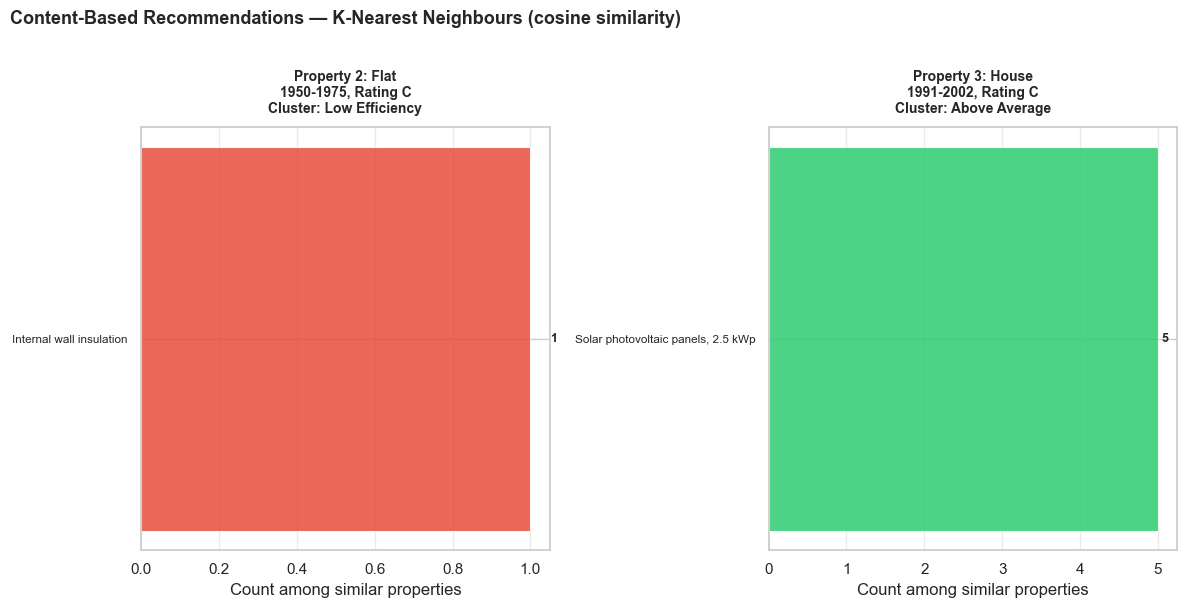

In [44]:
fig, axes = plt.subplots(1, min(len(sample_indices), 3), figsize=(17, 6))
if len(sample_indices) == 1:
    axes = [axes]

for pos, prop_idx in enumerate(sample_indices[:3]):
    ax = axes[pos]
    top_recs, cluster_lbl, _ = recommend_for_property(prop_idx)
    prop_row = df.iloc[prop_idx]
    if len(top_recs) == 0:
        ax.set_visible(False); continue
    clr = CLUSTER_COLORS[cluster_labels[prop_idx]]
    bars_cbf = ax.barh(range(len(top_recs)), top_recs.values[::-1],
                        color=clr, edgecolor='white', linewidth=0.8, height=0.6, alpha=0.85)
    ax.set_yticks(range(len(top_recs)))
    ax.set_yticklabels([t[:38]+'...' if len(t)>38 else t
                        for t in top_recs.index[::-1]], fontsize=8.5)
    for bar, val in zip(bars_cbf, top_recs.values[::-1]):
        ax.text(val+0.05, bar.get_y()+bar.get_height()/2,
                f'{val}', va='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Property {pos+1}: {prop_row["PROPERTY_TYPE"]}\n'
                 f'{prop_row["PROPERTY_AGE_GROUP"]}, Rating {prop_row["CURRENT_ENERGY_RATING"]}\n'
                 f'Cluster: {cluster_lbl}', pad=10, fontsize=10)
    ax.set_xlabel('Count among similar properties')
    ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

plt.suptitle('Content-Based Recommendations — K-Nearest Neighbours (cosine similarity)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart21_cbf_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Recommendations and Conclusions

### Summary of Analytical Findings

This analysis applied a complete data science pipeline to 4,579 EPC records for Liverpool (Local Authority E08000012), proceeding through descriptive, diagnostic, predictive, and prescriptive stages.

**Descriptive findings:**
- 68.6% of Liverpool properties are rated Band C — mid-range efficiency dominates the stock
- Flats outperform Houses by an average of 4.5 SAP points due to shared-wall heat retention
- 28.4% of stock was built before 1930, with the highest concentration of low-efficiency properties
- Owner-occupied properties carry the largest unrealised efficiency gap (8.9 SAP points average)

**Diagnostic findings:**
- Wall insulation quality is the single largest physical driver of efficiency — a 14-point range from Very Poor to Very Good
- Pre-1930 construction is the root cause of low efficiency; these properties lack cavity walls and require expensive solid wall insulation
- Band E properties emit 4× more CO2 than Band A — targeting this segment produces the highest carbon saving per retrofit
- Social rented stock shows the smallest efficiency gap, reflecting systematic housing association retrofit programmes

**Predictive findings:**
- Gradient Boosting classifier: **81.22% accuracy** on 25 physical building features (no data leakage)
- Random Forest: 80.79%, Logistic Regression: 76.53%
- Feature importance confirms wall insulation, roof insulation, and construction age as the dominant predictors
- Regression: RMSE = 3.63 SAP points, R² = 0.72 for efficiency score prediction

**Clustering and Prescription:**
- K-Means (K=4) identifies four natural property segments: Low Efficiency (30.4%), Below Average (62.7%), Above Average (1.5%), High Efficiency (5.5%)
- The recommendation system combines frequency-based population analysis with content-based personalised filtering
- Top city-wide recommendations: floor insulation, solar PV, cavity wall insulation

### Policy Recommendations

1. **Target pre-1930 wall insulation** — 28.4% of Liverpool stock with the highest single-feature efficiency gain potential; government subsidy (ECO4 scheme) should prioritise solid wall properties
2. **MEES compliance enforcement** — 5.9% of stock is in Band E; private rented sector landlords must reach Band C by 2028 under planned regulations (MHCLG, 2018)
3. **Owner-occupied retrofit finance** — the largest efficiency gap (8.9 points) is in owner-occupied stock with no regulatory obligation; green finance products and stamp duty incentives are required
4. **Community heat networks** — Liverpool's dense terraced housing stock is well-suited to district heating as an alternative to individual gas boiler replacement
5. **Deploy the ML pipeline operationally** — the 81.22% classifier and recommendation system can pre-screen properties before costly physical assessments, enabling targeted outreach

### References

- Branco, G., Lachal, B., Gallinelli, P. and Weber, W. (2004) 'Predicted versus observed heat consumption of a low energy multifamily complex in Switzerland', *Energy and Buildings*, 36(6), pp. 543–555.
- BRE (2023) *The Government's Standard Assessment Procedure for Energy Rating of Dwellings (SAP 10.2)*. Watford: Building Research Establishment.
- DESNZ (2023) *Energy Performance of Buildings Data: England and Wales*. Department for Energy Security and Net Zero. Available at: https://epc.opendatacommunities.org (Accessed: 13 June 2026).
- Kaufman, S., Rosset, S., Perlich, C. and Stitelman, O. (2012) 'Leakage in data mining: Formulation, detection, and avoidance', *ACM Transactions on Knowledge Discovery from Data*, 6(4), pp. 1–21.
- MHCLG (2018) *The Energy Efficiency (Private Rented Property) (England and Wales) Regulations 2015*. Ministry of Housing, Communities and Local Government. London: HMSO.
- Sunikka-Blank, M. and Galvin, R. (2012) 'Introducing the prebound effect: The gap between performance and actual energy consumption', *Building Research & Information*, 40(3), pp. 260–273.


In [45]:
print('Pipeline complete. Summary:')
summary_final = pd.DataFrame({
    'Item': [
        'Properties analysed',
        'Features after wrangling',
        'Predictive features (no leakage)',
        'K-Means clusters',
        'Charts generated',
        'Classification accuracy (GB)',
        'Classification CV score (GB)',
        'Regression RMSE — efficiency score (GB)',
        'Regression R2  — efficiency score (GB)',
        'Regression RMSE — cost saving (GB)',
        'Mean annual cost saving',
        'Cleaned dataset'
    ],
    'Value': [
        f'{len(df):,}',
        df.shape[1],
        len(feature_cols),
        optimal_k,
        21,
        f'{gb_acc:.4f}',
        f'{cv_gb.mean():.4f} (Gradient Boosting)',
        f'{rmse_val:.4f}',
        f'{r2_val:.4f}',
        f'GBP{rmse_c:.2f}',
        f'GBP{df["COST_SAVING_POTENTIAL"].mean():.2f}/property/year',
        'liverpool_epc_cleaned.csv'
    ]
})
display(summary_final)

Pipeline complete. Summary:


,Item,Value
0,Properties analysed,"4,579"
1,Features after wrangling,73
2,Predictive features (no leakage),25
3,K-Means clusters,4
4,Charts generated,21
5,Classification accuracy (GB),0.8122
6,Classification CV score (GB),0.8346 (Gradient Boosting)
7,Regression RMSE — efficiency score (GB),3.6343
8,Regression R2 — efficiency score (GB),0.7175
9,Regression RMSE — cost saving (GB),GBP72.01
